# Part 3 — Robustness, Uncertainty, and Label-Reference Sensitivity for Serial Alert-Burden Simulation

Part 3 adds no new model and changes nothing frozen in Part 2. It reads the saved
predictions and alert stream, reconstructs the primary estimand to prove it matches,
and then quantifies how far the result moves under resampling, threshold choice,
redundancy definition, cohort restriction, and an adjudicated label reference.

---

## 1. Objectives, analysis tiers, and interpretation boundaries

### 1.1 Two co-primary estimands

**A. Burden composition.** Among model-fired alerts in the held-out primary cohort, the
proportion that are false, redundant under `label_historical`, and first-observed
positive.

Because 87.5% of fired alerts are false at the frozen operating point, the composition is
also reported **conditional on the alert being correct**. That second view is not a
different analysis; it is the same counts with the false-alert mass removed from the
denominator, and it is the view in which the serial structure is visible rather than
swamped by discrimination.

**B. Differential detection.** The model's sensitivity for positive labels **first
observed** in the available test sequence, against its sensitivity for positive labels
**already seen** earlier in that sequence. Part 2 found 67.1% against 79.0% overall, with
12 of 13 pathologies in the same direction.

Estimand B was not part of the original Part 2 plan. It emerged from the frozen results
and is therefore declared here as **exploratory-confirmatory**: pre-specified for Part 3,
but generated by inspection of Part 2 output, not before it. That distinction is recorded
in the manifest and must survive into any write-up.

### 1.2 The severity confound, and why section 7 exists

Estimand B has an obvious alternative explanation. Findings that persist across several
radiographs are plausibly larger and more conspicuous than findings appearing for the
first time, so the gap could measure severity rather than anything about serial position.

Section 7 addresses this with a **within-episode analysis**: within a single run of
consecutive positive labels for one patient and one pathology, detection at the run's
first appearance is compared against detection at its later appearances. Patient and
finding are held constant. If the gap survives, severity confounding is substantially
reduced. If it vanishes, estimand B is a severity artefact and must be reported as one.

This is the analysis that decides whether estimand B stands. It is not optional.

### 1.3 Analysis tiers

| Tier | Contents |
|---|---|
| Primary | Exact reconstruction of the frozen Part 2 label-history result |
| Sensitivity | Bootstrap intervals, thresholds, redundancy definitions, cohorts, discrimination floor, adjudicated labels |
| Exploratory | Pathology and position heterogeneity, subgroups, policy dominance, score-change delta |

### 1.4 Interpretation boundaries carried forward

`Follow-up #` is ordinal. Nothing is reported per unit time. NIH labels are weak,
report-derived labels. `first_observed_positive_alert` means a positive weak label first
seen in the available test sequence, not incident disease or clinical actionability. A
repeat positive does not prove a re-alert would be clinically redundant. No clinician saw
any alert. No policy is safe, optimal, beneficial, or deployment-ready.

**On the label-history oracle.** It is a retrospective benchmark estimating the effect of
suppressing alerts for label-positive findings previously observed in the available
sequence. It is not deployable as specified, and it is **not** a universal upper bound on
what prediction-history policies can achieve: a prediction-history policy can suppress
alerts the oracle retains, so the two trace different trade-off curves rather than one
bounding the other. It is a reference point, nothing more.

## 2. Load and validate frozen Part 1 and Part 2 artifacts

Every check fails loudly. Part 3 must not silently proceed on artifacts that differ from
the ones Part 2 produced.

In [1]:
from __future__ import annotations

import gc, hashlib, json, os, platform, random, sys, time, warnings
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Callable, Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 90)

# ----------------------------- PATHS (edit these) -----------------------------
PART1_OUTPUT_DIR: Path = Path(r"C:\Users\kruta\Downloads\part1_outputs")
PART2_RUN_DIR: Path = Path(r"C:\Users\kruta\Downloads\part2_outputs\full_densenet121_sens50")
PART3_OUTPUT_DIR: Path = Path(r"C:\Users\kruta\Downloads\part3_outputs")
GOOGLE_LABELS_DIR: Path = Path(r"C:\Users\kruta\Downloads\NIH Chest X-rays")
# ------------------------------------------------------------------------------

P1_CACHE, P1_LOGS = PART1_OUTPUT_DIR / "cache", PART1_OUTPUT_DIR / "logs"
P2_TABLES, P2_LOGS = PART2_RUN_DIR / "tables", PART2_RUN_DIR / "logs"


def require_artifact(path: Path, what: str) -> Path:
    """Return `path` or raise naming what is missing and what the folder does contain."""
    p = Path(path)
    if p.exists():
        return p
    parent = p.parent
    listing = sorted(x.name for x in parent.iterdir())[:30] if parent.exists() else []
    raise FileNotFoundError(
        f"Missing artifact: {what}\n  expected: {p}\n"
        f"  parent {'exists' if parent.exists() else 'MISSING'}; contains: {listing}")


def load_any_table(stem: Path, what: str) -> pd.DataFrame:
    """Read a table saved as .parquet, .csv or .csv.gz, whichever exists."""
    for suffix, reader in ((".parquet", pd.read_parquet), (".csv", pd.read_csv),
                           (".csv.gz", pd.read_csv)):
        cand = Path(str(stem) + suffix) if suffix == ".csv.gz" else stem.with_suffix(suffix)
        if cand.exists():
            return reader(cand)
    require_artifact(stem.with_suffix(".csv"), what)
    raise AssertionError("unreachable")


P1_MANIFEST = json.loads(require_artifact(P1_LOGS / "part1_run_manifest.json",
                                          "Part 1 manifest").read_text())
P2_MANIFEST = json.loads(require_artifact(P2_LOGS / "part2_run_manifest.json",
                                          "Part 2 manifest").read_text())
P2_CONFIG = json.loads(require_artifact(P2_LOGS / "part2_config.json",
                                        "Part 2 config").read_text())

STREAM = pd.read_parquet(require_artifact(P2_TABLES / "test_alert_stream.parquet",
                                          "frozen alert stream"))
PRED = pd.read_parquet(require_artifact(P2_TABLES / "test_predictions_long.parquet",
                                        "frozen test predictions"))
THRESHOLDS = load_any_table(P2_TABLES / "selected_thresholds", "selected thresholds")
TEST_METRICS = load_any_table(P2_TABLES / "test_image_level_metrics", "test metrics")
VAL_GRID = load_any_table(P2_TABLES / "validation_threshold_grid", "validation grid")
VAL_METRICS = load_any_table(P2_TABLES / "validation_metrics", "validation metrics")
LABEL_REPORT = load_any_table(P2_TABLES / "pathology_selection_report", "label report")
SPLIT_ASSIGN = load_any_table(P2_TABLES / "patient_split_assignments", "split assignments")
P2_BURDEN_LABEL = load_any_table(P2_TABLES / "primary_alert_burden_label_history",
                                 "Part 2 label-history burden")
P2_BURDEN_PRED = load_any_table(P2_TABLES / "primary_alert_burden_prediction_history",
                                "Part 2 prediction-history burden")
P2_POLICY = load_any_table(P2_TABLES / "suppression_policy_comparison", "Part 2 policies")
P2_AUDIT = load_any_table(P2_TABLES / "part2_audit_checklist", "Part 2 audit")

PATHOLOGIES: List[str] = list(P2_MANIFEST["primary_labels"])
THRESH_MAP: Dict[str, float] = {k: float(v) for k, v in
                                P2_MANIFEST["selected_thresholds"].items()}

# Part 1 wide table supplies sequence-integrity flags the stream does not carry.
_p1_wide_stem = P1_CACHE / "part1_image_level"
P1_WIDE = load_any_table(_p1_wide_stem, "Part 1 image-level table")


def validate_part1_part2_fingerprint_alignment() -> Dict[str, object]:
    """Confirm Part 2 consumed the Part 1 artifact its manifest names."""
    p1_fp = str(P1_MANIFEST["dataset_fingerprint"])
    p2_seen = P2_MANIFEST.get("part1_fingerprint", {})
    ok = str(p2_seen.get("fingerprint_manifest")) == p1_fp
    if not ok:
        warnings.warn(f"Fingerprint mismatch. Part 1 manifest {p1_fp[:12]}, Part 2 recorded "
                      f"{str(p2_seen.get('fingerprint_manifest'))[:12]}. Investigate before "
                      "trusting any result.", UserWarning)
    return {"part1_fingerprint": p1_fp, "part2_recorded": p2_seen, "aligned": ok}


def validate_test_prediction_schema(pred: pd.DataFrame) -> None:
    need = ["Image Index", "Patient ID", "split", "pathology", "probability",
            "label_current", "threshold", "sequence_position_ordinal"]
    missing = [c for c in need if c not in pred.columns]
    if missing:
        raise KeyError(f"test predictions missing columns: {missing}")
    bad = set(pred["pathology"].astype(str)) - set(PATHOLOGIES)
    if bad:
        raise ValueError(f"predictions contain pathologies outside the frozen label set: "
                         f"{sorted(bad)}")
    if set(PATHOLOGIES) - set(pred["pathology"].astype(str)):
        raise ValueError("frozen predictions do not cover every selected label")


def validate_stream_schema(s: pd.DataFrame) -> None:
    need = ["Image Index", "Patient ID", "split", "pathology", "probability", "threshold",
            "label_current", "model_fires", "label_ever_prior", "label_prior_encounter",
            "fired_ever_prior", "fired_prior_encounter", "prior_probability",
            "is_index_encounter", "is_test_sequence_warmup_encounter", "in_primary_cohort",
            "sequence_position_ordinal", "strict_history_eligible", "age_consistent",
            "sex_group", "age_band", "projection_group"]
    missing = [c for c in need if c not in s.columns]
    if missing:
        raise KeyError(f"alert stream missing columns: {missing}")


def validate_selected_thresholds(t: pd.DataFrame) -> None:
    if set(t["pathology"]) != set(PATHOLOGIES):
        raise ValueError("selected thresholds do not cover exactly the frozen label set")
    if not t["threshold"].between(0, 1).all():
        raise ValueError("a selected threshold lies outside [0, 1]")
    if "selected_on" in t.columns and not (t["selected_on"] == "validation_split_only").all():
        raise ValueError("a threshold was not derived from validation data only")


def assert_patient_disjointness(assign: pd.DataFrame) -> int:
    n = int((assign.groupby("Patient ID")["split"].nunique() > 1).sum())
    if n:
        raise ValueError(f"{n} patients appear in more than one split")
    return n


def assert_test_only_stream(s: pd.DataFrame) -> None:
    if not (s["split"] == "test").all():
        raise ValueError("alert stream contains non-test rows")


def assert_no_duplicate_image_pathology_rows(d: pd.DataFrame, what: str) -> None:
    if d.duplicated(["Image Index", "pathology"]).any():
        raise ValueError(f"{what} contains duplicate (Image Index, pathology) rows")


def assert_primary_cohort_has_no_index_or_warmup_rows(d: pd.DataFrame) -> None:
    if bool(d["is_index_encounter"].any()):
        raise ValueError("primary cohort contains index encounters")
    if bool(d["is_test_sequence_warmup_encounter"].any()):
        raise ValueError("primary cohort contains test-sequence warm-up encounters")


def assert_primary_categories_mutually_exclusive(cats: pd.Series, n: int,
                                                 allowed: Sequence[str]) -> None:
    vc = cats.value_counts()
    unknown = set(vc.index) - set(allowed)
    if unknown:
        raise ValueError(f"unrecognised alert categories: {sorted(unknown)}")
    if int(vc.sum()) != n or cats.isna().any():
        raise ValueError(f"category assignment covers {int(vc.sum()):,} of {n:,} rows")


FP = validate_part1_part2_fingerprint_alignment()
validate_test_prediction_schema(PRED)
validate_stream_schema(STREAM)
validate_selected_thresholds(THRESHOLDS)
assert_patient_disjointness(SPLIT_ASSIGN)
assert_test_only_stream(STREAM)
assert_no_duplicate_image_pathology_rows(PRED, "test predictions")
assert_no_duplicate_image_pathology_rows(STREAM, "alert stream")

_p2_fail = P2_AUDIT[P2_AUDIT["status"] == "FAIL"]
if len(_p2_fail):
    raise RuntimeError("Part 2 audit contains FAIL items; resolve them before Part 3:\n"
                       + _p2_fail.to_string(index=False))
_p2_warn = int((P2_AUDIT["status"] == "WARN").sum())

print(f"Part 2 run           : {P2_MANIFEST['run_tag']}")
print(f"Backbone             : {P2_MANIFEST['embedding_meta'].get('backbone_id')}")
print(f"Labels               : {len(PATHOLOGIES)}")
print(f"Alert stream rows    : {len(STREAM):,}")
print(f"Test patients        : {STREAM['Patient ID'].nunique():,}")
print(f"Part 2 audit         : 0 FAIL, {_p2_warn} WARN")
print(f"Fingerprint aligned  : {FP['aligned']}")
print("All structural validations passed.")

C:\Users\kruta\anaconda3-v2\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Part 2 run           : full_densenet121_sens50
Backbone             : densenet121_xrv_mimic_ch
Labels               : 13
Alert stream rows    : 332,748
Test patients        : 2,797
Part 2 audit         : 0 FAIL, 0 WARN
Fingerprint aligned  : True
All structural validations passed.


## 3. Configuration, reproducibility, and computational safeguards

**On bootstrap cost.** A naive patient-clustered bootstrap that re-slices a 296,000-row
stream 1,000 times is slow and memory-hungry. Everything needed here is a sum or a ratio
of sums over patients, so the stream is aggregated to one row per patient **once**, and
each replicate is then a sum over a resampled index. That makes 1,000 replicates a matter
of seconds and removes any need to copy the stream. Metrics that are not sums (the median
alerts per patient) operate on the per-patient vector directly, which is equally cheap.

Chunked on-disk checkpointing is still implemented, because the design requires
resumability even when the run is fast.

In [2]:
RANDOM_SEED: int = 42
FAST_MODE: bool = False              # True -> 200 replicates, separate output folder

N_BOOTSTRAP_FULL: int = 1000
N_BOOTSTRAP_FAST: int = 200
MAX_BOOTSTRAP_WITHOUT_CONFIRMATION: int = 1000
ALLOW_LARGE_BOOTSTRAP: bool = False
BOOTSTRAP_CHUNK: int = 100
CI_ALPHA: float = 0.05
N_JOBS: int = 1

THRESHOLD_GRID = np.round(np.arange(0.10, 0.91, 0.05), 3)
FIXED_THRESHOLDS = (0.50, 0.75)
ALT_SENSITIVITY_FLOOR: float = 0.80          # recomputed from the saved validation grid

SCORE_CHANGE_DELTAS = (0.05, 0.10, 0.20)
SEQUENCE_POSITION_K: int = 8

MIN_PATHOLOGY_FIRED_ALERTS_FOR_CI: int = 100
MIN_PATHOLOGY_POSITIVES_FOR_CI: int = 50
MIN_PATHOLOGY_PATIENTS_FOR_CI: int = 25
MIN_SUBGROUP_PATIENTS: int = 25
MIN_SUBGROUP_IMAGES: int = 100
MIN_SUBGROUP_POSITIVES: int = 10
MIN_SUBGROUP_FIRED: int = 50

# Pre-specified discrimination floor, applied to VALIDATION AUROC only. Using test AUROC
# to drop labels would be selection on the outcome; the validation figure is admissible.
VALIDATION_AUROC_FLOOR: float = 0.65

MIN_EPISODE_LENGTH: int = 2                  # within-episode severity analysis

ALERT_CATEGORIES = ("false_alert", "redundant_alert", "first_observed_positive_alert",
                    "missed_positive", "true_silence")
FIRED_CATEGORIES = ALERT_CATEGORIES[:3]
REDUNDANCY_PREDICATES = ("label_historical", "label_immediate_prior",
                         "prediction_historical", "prediction_immediate_prior")
PRIMARY_REDUNDANCY = "label_historical"

random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

RUN_TAG = "smoke" if FAST_MODE else "full"
N_BOOT = N_BOOTSTRAP_FAST if FAST_MODE else N_BOOTSTRAP_FULL
if N_BOOT > MAX_BOOTSTRAP_WITHOUT_CONFIRMATION and not ALLOW_LARGE_BOOTSTRAP:
    raise RuntimeError(f"N_BOOT={N_BOOT} exceeds "
                       f"{MAX_BOOTSTRAP_WITHOUT_CONFIRMATION}; set ALLOW_LARGE_BOOTSTRAP.")

OUT = PART3_OUTPUT_DIR / RUN_TAG
TABLES, FIGURES, BOOT_DIR, LOGS = (OUT / "tables", OUT / "figures",
                                   OUT / "bootstrap_chunks", OUT / "logs")
for d in (OUT, TABLES, FIGURES, BOOT_DIR, LOGS):
    d.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="colorblind", font_scale=0.9)
matplotlib.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight"})
CB = sns.color_palette("colorblind")
_SAVED_TABLES: List[str] = []
_SAVED_FIGURES: List[str] = []
NOT_ESTIMABLE: List[Dict[str, object]] = []


def save_table(df: pd.DataFrame, name: str, index: bool = False,
               parquet_too: bool = False) -> Path:
    """Write a table under the run-tagged folder, stamped with smoke-test status."""
    out = df.copy()
    out["smoke_test"] = FAST_MODE
    stem = name[:-4] if name.endswith(".csv") else name
    path = TABLES / f"{stem}.csv"
    out.to_csv(path, index=index)
    if parquet_too:
        out.to_parquet(TABLES / f"{stem}.parquet", index=index)
    if f"{stem}.csv" not in _SAVED_TABLES:
        _SAVED_TABLES.append(f"{stem}.csv")
    print(f"  table  -> {stem}.csv  ({len(df):,} x {df.shape[1]})")
    return path


def save_figure(fig: plt.Figure, name: str) -> Path:
    stem = name[:-4] if name.endswith(".png") else name
    path = FIGURES / f"{stem}.png"
    fig.savefig(path)
    if f"{stem}.png" not in _SAVED_FIGURES:
        _SAVED_FIGURES.append(f"{stem}.png")
    print(f"  figure -> {stem}.png")
    return path


def record_not_estimable(analysis: str, reason: str, n_available: object,
                         required: str) -> None:
    """Register a planned analysis that could not be run, with its blocking condition."""
    NOT_ESTIMABLE.append({"analysis": analysis, "status": "not_estimable",
                          "reason": reason, "available_sample_size": n_available,
                          "required_condition_failed": required})
    warnings.warn(f"NOT ESTIMABLE: {analysis} - {reason}", UserWarning)


class timed:
    def __init__(self, label: str): self.label = label
    def __enter__(self): self.t0 = time.perf_counter(); print(f"[start] {self.label}"); return self
    def __exit__(self, *e):
        dt = time.perf_counter() - self.t0
        print(f"[done ] {self.label} ({dt:.1f} s)" if dt < 90 else
              f"[done ] {self.label} ({dt/60:.1f} min)")
        return False


CONFIG = {k: (str(v) if isinstance(v, Path) else
              (list(v) if isinstance(v, (tuple, np.ndarray)) else v))
          for k, v in sorted(globals().items())
          if k.isupper() and isinstance(v, (int, float, str, bool, Path, tuple, np.ndarray))
          and not k.startswith("_")}
CONFIG.update({"created_utc": datetime.now(timezone.utc).isoformat(),
               "python": sys.version.split()[0],
               "platform": f"{platform.system()} {platform.release()}",
               "n_bootstrap": N_BOOT, "run_tag": RUN_TAG,
               "estimand_B_status": "exploratory-confirmatory: pre-specified for Part 3, "
                                    "generated by inspection of frozen Part 2 output"})
(LOGS / "part3_config.json").write_text(json.dumps(CONFIG, indent=2, default=str))
print(f"RUN_TAG={RUN_TAG} | bootstrap replicates={N_BOOT} | outputs -> {OUT}")

RUN_TAG=full | bootstrap replicates=1000 | outputs -> C:\Users\kruta\Downloads\part3_outputs\full


## 4. Reconstruct and verify the frozen primary estimand

The primary cohort and category assignment are rebuilt from the frozen stream and
checked numerically against the Part 2 burden table. A mismatch stops the notebook.

Three additions beyond reconstruction:

1. **Composition among correct alerts.** With 87.5% of fired alerts false, the serial
   structure is invisible in the unconditional split. The conditional view is the same
   counts with a different denominator, reported alongside, never instead.
2. **Alert multiplicity.** One radiograph yields up to 13 alerts, so "alerts per 100
   radiographs" exceeds 100 and must never be read as a percentage of radiographs. The
   multiplicity table makes the distinction explicit.
3. **Estimand B**, the first-observed against repeat detection gap.

In [3]:
def classify(stream: pd.DataFrame, predicate: str,
             fires_col: str = "model_fires") -> pd.Series:
    """Assign one mutually exclusive alert category per row under a redundancy predicate."""
    pred = {
        "label_historical": stream["label_ever_prior"].fillna(False).astype(bool),
        "label_immediate_prior": stream["label_prior_encounter"].eq(1),
        "prediction_historical": stream["fired_ever_prior"].fillna(False).astype(bool),
        "prediction_immediate_prior": stream["fired_prior_encounter"].eq(1),
    }[predicate]
    fires = stream[fires_col] == 1
    pos = stream["label_current"] == 1
    return pd.Series(np.select(
        [fires & ~pos, fires & pos & pred, fires & pos & ~pred, ~fires & pos],
        list(FIRED_CATEGORIES) + ["missed_positive"], default="true_silence"),
        index=stream.index)


PRIMARY = STREAM[STREAM["in_primary_cohort"]].copy()
assert_primary_cohort_has_no_index_or_warmup_rows(PRIMARY)
PRIMARY["alert_category"] = classify(PRIMARY, PRIMARY_REDUNDANCY)
assert_primary_categories_mutually_exclusive(PRIMARY["alert_category"], len(PRIMARY),
                                             ALERT_CATEGORIES)

n_img = PRIMARY["Image Index"].nunique()
n_pt = PRIMARY["Patient ID"].nunique()
n_opp = len(PRIMARY)
counts = PRIMARY["alert_category"].value_counts()
n_fired = int(sum(counts.get(c, 0) for c in FIRED_CATEGORIES))
n_correct = int(counts.get("redundant_alert", 0)
                + counts.get("first_observed_positive_alert", 0))

recon = []
for cat in ALERT_CATEGORIES:
    n = int(counts.get(cat, 0))
    recon.append({
        "alert_category": cat, "n": n,
        "per_100_followup_images": round(100 * n / n_img, 4),
        "per_patient": round(n / n_pt, 5),
        "per_100_patient_pathology_opportunities": round(100 * n / n_opp, 5),
        "share_of_fired_alerts_pct": round(100 * n / n_fired, 4)
        if cat in FIRED_CATEGORIES else np.nan,
        "share_of_correct_alerts_pct": round(100 * n / n_correct, 4)
        if cat in FIRED_CATEGORIES[1:] and n_correct else np.nan,
    })
recon = pd.DataFrame(recon)
recon["n_followup_images"], recon["n_patients"] = n_img, n_pt
recon["n_patient_pathology_opportunities"], recon["total_fired"] = n_opp, n_fired
recon["total_correct_alerts"] = n_correct
save_table(recon, "part3_primary_estimand_reconstruction")

print(f"\nTest patients {STREAM['Patient ID'].nunique():,} | primary-cohort patients "
      f"{n_pt:,} | follow-up images {n_img:,} | opportunities {n_opp:,}")
print(recon[["alert_category", "n", "per_100_followup_images", "per_patient",
             "share_of_fired_alerts_pct", "share_of_correct_alerts_pct"]].to_string(index=False))

# --------------------- numerical check against Part 2 -------------------------
p2 = P2_BURDEN_LABEL.set_index("alert_category")["n"].astype(int)
diffs = {c: int(counts.get(c, 0)) - int(p2.get(c, -1)) for c in ALERT_CATEGORIES}
if any(v != 0 for v in diffs.values()):
    raise RuntimeError(f"Primary reconstruction does not match Part 2: {diffs}")
print(f"\nReconstruction matches the frozen Part 2 primary result exactly "
      f"({n_fired:,} fired alerts, all five categories identical).")

print(f"\nAmong correct alerts only (n={n_correct:,}): "
      f"redundant {100*counts.get('redundant_alert',0)/n_correct:.1f}%, "
      f"first-observed {100*counts.get('first_observed_positive_alert',0)/n_correct:.1f}%. "
      "Same counts, denominator excludes false alerts.")

  table  -> part3_primary_estimand_reconstruction.csv  (5 x 12)

Test patients 2,797 | primary-cohort patients 1,424 | follow-up images 22,799 | opportunities 296,387
               alert_category      n  per_100_followup_images  per_patient  share_of_fired_alerts_pct  share_of_correct_alerts_pct
                  false_alert 139032                 609.8162     97.63483                    87.5202                          NaN
              redundant_alert  16385                  71.8672     11.50632                    10.3143                      82.6482
first_observed_positive_alert   3440                  15.0884      2.41573                     2.1655                      17.3518
              missed_positive   6031                  26.4529      4.23525                        NaN                          NaN
                 true_silence 131499                 576.7753     92.34480                        NaN                          NaN

Reconstruction matches the frozen Part 2 prima

In [4]:
# ------------------------- alert multiplicity ---------------------------------
fired_mask = PRIMARY["alert_category"].isin(FIRED_CATEGORIES)
per_image = (PRIMARY[fired_mask].groupby("Image Index").size()
             .reindex(PRIMARY["Image Index"].unique(), fill_value=0))
bins = per_image.clip(upper=4).value_counts().sort_index()
mult = pd.DataFrame({
    "fired_alerts_on_radiograph": ["0", "1", "2", "3", "4 or more"],
    "n_radiographs": [int(bins.get(i, 0)) for i in range(5)]})
mult["pct_of_radiographs"] = (100 * mult["n_radiographs"] / n_img).round(3)
mult_summary = pd.DataFrame([
    ("n_radiographs", n_img), ("n_selected_pathologies", len(PATHOLOGIES)),
    ("mean_fired_per_radiograph", round(float(per_image.mean()), 4)),
    ("median_fired_per_radiograph", float(per_image.median())),
    ("iqr_fired_per_radiograph",
     f"{per_image.quantile(.25):.0f}-{per_image.quantile(.75):.0f}"),
    ("max_fired_per_radiograph", int(per_image.max())),
    ("pct_radiographs_with_at_least_one_alert",
     round(100 * float((per_image > 0).mean()), 3)),
], columns=["metric", "value"])
save_table(mult, "part3_primary_alert_multiplicity")
print(mult.to_string(index=False)); print(); print(mult_summary.to_string(index=False))
print(f"\n{n_fired/n_img*100:.0f} alerts per 100 radiographs is NOT "
      f"{n_fired/n_img*100:.0f}% of radiographs: each radiograph carries up to "
      f"{len(PATHOLOGIES)} pathology opportunities and "
      f"{100*float((per_image > 0).mean()):.1f}% of radiographs receive at least one alert.")

per_patient_fired = (PRIMARY[fired_mask].groupby("Patient ID").size()
                     .reindex(PRIMARY["Patient ID"].unique(), fill_value=0))
pt_dist = pd.DataFrame({
    "metric": ["n_patients", "mean", "median", "q25", "q75", "q90", "max",
               "pct_patients_with_at_least_one_alert"],
    "value": [n_pt, round(float(per_patient_fired.mean()), 3),
              float(per_patient_fired.median()), float(per_patient_fired.quantile(.25)),
              float(per_patient_fired.quantile(.75)), float(per_patient_fired.quantile(.90)),
              int(per_patient_fired.max()),
              round(100 * float((per_patient_fired > 0).mean()), 3)]})
save_table(pt_dist, "part3_primary_patient_alert_distribution")
print(); print(pt_dist.to_string(index=False))

  table  -> part3_primary_alert_multiplicity.csv  (5 x 3)
fired_alerts_on_radiograph  n_radiographs  pct_of_radiographs
                         0            413               1.811
                         1            812               3.562
                         2           1033               4.531
                         3           1139               4.996
                 4 or more          19402              85.100

                                 metric   value
                          n_radiographs   22799
                 n_selected_pathologies      13
              mean_fired_per_radiograph  6.9677
            median_fired_per_radiograph     7.0
               iqr_fired_per_radiograph     5-9
               max_fired_per_radiograph      13
pct_radiographs_with_at_least_one_alert  98.189

697 alerts per 100 radiographs is NOT 697% of radiographs: each radiograph carries up to 13 pathology opportunities and 98.2% of radiographs receive at least one alert.
  table  -> par

In [5]:
# ------------- estimand B: first-observed vs repeat detection -----------------
def detection_gap(d: pd.DataFrame) -> pd.DataFrame:
    """Sensitivity for first-observed against repeat positive labels."""
    pos = d[d["label_current"] == 1].copy()
    pos["prior_positive"] = pos["label_ever_prior"].fillna(False).astype(bool)
    pos["detected"] = pos["model_fires"] == 1
    g = pos.groupby("prior_positive")["detected"].agg(n="size", detected="sum")
    g["sensitivity"] = g["detected"] / g["n"]
    return g


gap = detection_gap(PRIMARY)
fo_s = float(gap.loc[False, "sensitivity"]); rp_s = float(gap.loc[True, "sensitivity"])
print(f"Estimand B, overall: first-observed {fo_s:.4f} (n={int(gap.loc[False,'n']):,}) | "
      f"repeat {rp_s:.4f} (n={int(gap.loc[True,'n']):,}) | "
      f"gap {100*(rp_s - fo_s):+.2f} pp")

gap_path = []
for p in PATHOLOGIES:
    g = detection_gap(PRIMARY[PRIMARY["pathology"] == p])
    row = {"pathology": p}
    for key, lab in ((False, "first_observed"), (True, "repeat")):
        row[f"n_{lab}"] = int(g.loc[key, "n"]) if key in g.index else 0
        row[f"sens_{lab}"] = round(float(g.loc[key, "sensitivity"]), 4) \
            if key in g.index else np.nan
    row["gap_pp"] = round(100 * (row["sens_repeat"] - row["sens_first_observed"]), 3)
    gap_path.append(row)
gap_path = pd.DataFrame(gap_path).sort_values("gap_pp", ascending=False)
save_table(gap_path, "part3_detection_gap_by_pathology")
print(); print(gap_path.to_string(index=False))
_same = int((gap_path["gap_pp"] > 0).sum())
print(f"\n{_same} of {len(gap_path)} pathologies show a positive gap. Direction "
      "consistency is reported; section 7 tests whether it survives severity control.")

Estimand B, overall: first-observed 0.6710 (n=5,127) | repeat 0.7904 (n=20,729) | gap +11.95 pp
  table  -> part3_detection_gap_by_pathology.csv  (13 x 6)

         pathology  n_first_observed  sens_first_observed  n_repeat  sens_repeat  gap_pp
          Effusion               635               0.4740      3885       0.6641   19.01
              Mass               287               0.5087      1295       0.6687   16.00
      Infiltration               699               0.7682      5188       0.9082   14.00
             Edema               312               0.6891       599       0.8130   12.39
      Cardiomegaly               243               0.4568       731       0.5705   11.37
Pleural_Thickening               345               0.7623       696       0.8678   10.55
       Atelectasis               642               0.7072      2480       0.8097   10.25
            Nodule               381               0.5328      1084       0.6172    8.44
     Consolidation               486       

## 5. Patient-clustered bootstrap uncertainty estimation

Patients are the resampling unit. All of a patient's image-pathology rows travel together
as a cluster, sequence order is preserved, no model is retrained, no threshold is
reselected, and the frozen probabilities are used throughout.

Implementation note: every quantity below is a sum, a ratio of sums, or an order
statistic over per-patient values, so the stream is collapsed to one row per patient once
and each replicate is an indexed sum. Chunks are checkpointed to disk so an interrupted
run resumes.

[start] patient-clustered bootstrap (1000 replicates, 1,424 patients)
  chunk     0: 100/1,000
  chunk   100: 200/1,000
  chunk   200: 300/1,000
  chunk   300: 400/1,000
  chunk   400: 500/1,000
  chunk   500: 600/1,000
  chunk   600: 700/1,000
  chunk   700: 800/1,000
  chunk   800: 900/1,000
  chunk   900: 1,000/1,000
[done ] patient-clustered bootstrap (1000 replicates, 1,424 patients) (1.3 s)
  table  -> part3_primary_bootstrap_ci.csv  (18 x 8)
  table  -> part3_policy_bootstrap_ci.csv  (25 x 8)

                             metric  point_estimate  ci_lower  ci_upper  unstable
     alerts_per_100_followup_images        696.7718  682.6602  708.7315     False
              false_alert_share_pct         87.5202   87.1840   87.8249     False
                redundant_share_pct         10.3143    9.9919   10.6490     False
           first_observed_share_pct          2.1655    2.0397    2.3035     False
     redundant_share_of_correct_pct         82.6482   81.5697   83.7032     False
fi

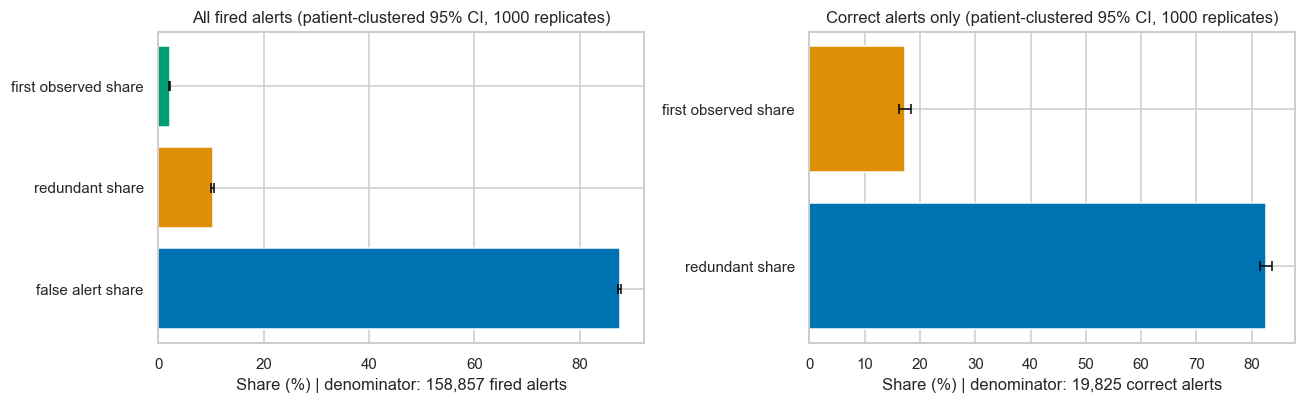

  figure -> fig02_multiplicity_and_patient_distribution.png


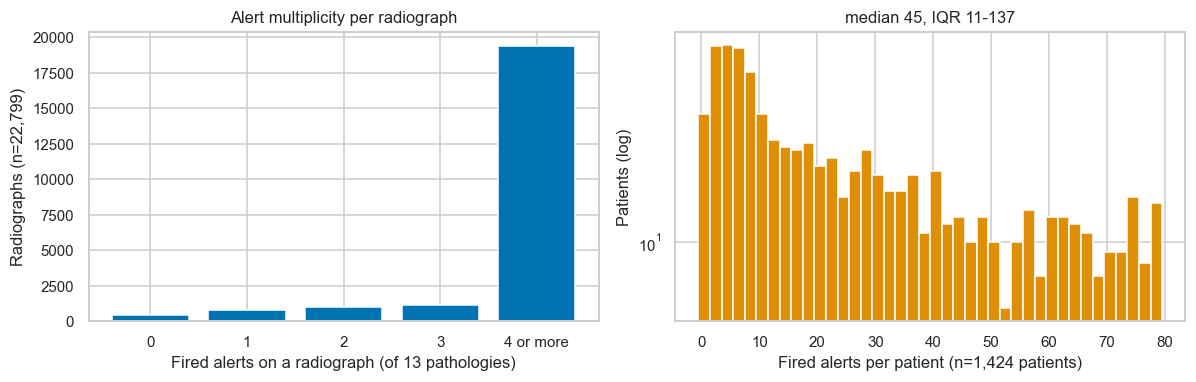

In [6]:
POLICIES = ["baseline", "prediction_one_alert_ever",
            "prediction_immediate_repeat_or_threshold_crossing",
            "prediction_score_change", "label_historical_oracle"]
POLICY_STATUS = {
    "baseline": "reference",
    "prediction_one_alert_ever": "deployable_style",
    "prediction_immediate_repeat_or_threshold_crossing": "deployable_style",
    "prediction_score_change": "deployable_style",
    "label_historical_oracle": "retrospective_oracle_benchmark_not_deployable"}


def apply_policy(d: pd.DataFrame, policy: str, delta: float = 0.10) -> pd.Series:
    """Boolean firing decision for one simulated policy on a frozen stream."""
    fires = d["model_fires"] == 1
    if policy == "baseline":
        return fires
    if policy == "prediction_one_alert_ever":
        return fires & ~d["fired_ever_prior"].fillna(False).astype(bool)
    if policy == "prediction_immediate_repeat_or_threshold_crossing":
        return fires & ~d["fired_prior_encounter"].eq(1)
    if policy == "prediction_score_change":
        pp = d["prior_probability"]
        return fires & pp.notna() & ((d["probability"] - pp) >= delta)
    if policy == "label_historical_oracle":
        return fires & ~d["label_ever_prior"].fillna(False).astype(bool)
    raise ValueError(f"unknown policy {policy!r}")


def build_patient_aggregate(d: pd.DataFrame) -> pd.DataFrame:
    """Collapse the stream to one row of sufficient statistics per patient.

    Every bootstrap metric is a sum, a ratio of sums, or an order statistic over these
    columns, so replicates never touch the full stream again.
    """
    x = d.copy()
    cat = x["alert_category"]
    x["_fired"] = cat.isin(FIRED_CATEGORIES).astype(np.int32)
    for c in ALERT_CATEGORIES:
        x[f"_{c}"] = (cat == c).astype(np.int32)
    pos = x["label_current"] == 1
    prior = x["label_ever_prior"].fillna(False).astype(bool)
    det = x["model_fires"] == 1
    x["_fo_pos"] = (pos & ~prior).astype(np.int32)
    x["_fo_det"] = (pos & ~prior & det).astype(np.int32)
    x["_rep_pos"] = (pos & prior).astype(np.int32)
    x["_rep_det"] = (pos & prior & det).astype(np.int32)

    base_fire = apply_policy(x, "baseline")
    x["_base_fo"] = (base_fire & pos & ~prior).astype(np.int32)
    for pol in POLICIES:
        f = apply_policy(x, pol)
        x[f"_pol_{pol}"] = f.astype(np.int32)
        x[f"_polfo_{pol}"] = (f & pos & ~prior).astype(np.int32)

    sum_cols = [c for c in x.columns if c.startswith("_")]
    agg = x.groupby("Patient ID")[sum_cols].sum()
    agg["n_images"] = x.groupby("Patient ID")["Image Index"].nunique()
    agg["n_opps"] = x.groupby("Patient ID").size()
    img_alert = (x[x["_fired"] == 1].groupby("Patient ID")["Image Index"].nunique()
                 .reindex(agg.index, fill_value=0))
    agg["n_images_with_alert"] = img_alert
    for pol in POLICIES:
        agg[f"_lost_{pol}"] = ((agg["_base_fo"] > 0)
                               & (agg[f"_polfo_{pol}"] == 0)).astype(np.int32)
    return agg


def compute_primary_estimands(agg: pd.DataFrame,
                              idx: Optional[np.ndarray] = None) -> Dict[str, float]:
    """Summary statistics from patient-level sufficient statistics.

    `idx` selects rows (with replacement for a bootstrap replicate); None uses all.
    """
    a = agg.to_numpy() if idx is None else agg.to_numpy()[idx]
    col = {c: i for i, c in enumerate(agg.columns)}
    s = a.sum(axis=0)
    g = lambda c: float(s[col[c]])
    npt = a.shape[0]
    fired = g("_fired")
    correct = g("_redundant_alert") + g("_first_observed_positive_alert")
    imgs = g("n_images")
    r = lambda num, den: float(num / den) if den else np.nan

    out = {
        "total_fired_alerts": fired,
        "alerts_per_100_followup_images": 100 * r(fired, imgs),
        "alerts_per_patient": r(fired, npt),
        "false_alert_share_pct": 100 * r(g("_false_alert"), fired),
        "redundant_share_pct": 100 * r(g("_redundant_alert"), fired),
        "first_observed_share_pct": 100 * r(g("_first_observed_positive_alert"), fired),
        "redundant_share_of_correct_pct": 100 * r(g("_redundant_alert"), correct),
        "first_observed_share_of_correct_pct":
            100 * r(g("_first_observed_positive_alert"), correct),
        "false_alert_per_100_images": 100 * r(g("_false_alert"), imgs),
        "redundant_per_100_images": 100 * r(g("_redundant_alert"), imgs),
        "first_observed_per_100_images":
            100 * r(g("_first_observed_positive_alert"), imgs),
        "missed_positive_n": g("_missed_positive"),
        "mean_alerts_per_image": r(fired, imgs),
        "pct_images_with_at_least_one_alert": 100 * r(g("n_images_with_alert"), imgs),
        "sens_first_observed": r(g("_fo_det"), g("_fo_pos")),
        "sens_repeat": r(g("_rep_det"), g("_rep_pos")),
    }
    out["detection_gap_pp"] = 100 * (out["sens_repeat"] - out["sens_first_observed"])
    out["median_alerts_per_patient"] = float(np.median(a[:, col["_fired"]]))

    base_n = g("_pol_baseline"); base_fo = g("_base_fo")
    for pol in POLICIES:
        n = g(f"_pol_{pol}")
        out[f"policy_{pol}_fired"] = n
        out[f"policy_{pol}_per_100_images"] = 100 * r(n, imgs)
        out[f"policy_{pol}_pct_reduction"] = 100 * r(base_n - n, base_n)
        out[f"policy_{pol}_first_observed_retention_pct"] = 100 * r(g(f"_polfo_{pol}"),
                                                                   base_fo)
        out[f"policy_{pol}_patients_losing_all_first_observed"] = g(f"_lost_{pol}")
    return out


def save_bootstrap_chunk(df: pd.DataFrame, start: int) -> Path:
    p = BOOT_DIR / f"boot_{start:06d}.parquet"
    df.to_parquet(p, index=False)
    return p


def load_completed_bootstrap_chunks() -> Tuple[pd.DataFrame, set]:
    files = sorted(BOOT_DIR.glob("boot_*.parquet"))
    if not files:
        return pd.DataFrame(), set()
    df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    return df, {int(f.stem.split("_")[1]) for f in files}


def resume_cluster_bootstrap(agg: pd.DataFrame, n_boot: int = N_BOOT,
                             chunk: int = BOOTSTRAP_CHUNK,
                             seed: int = RANDOM_SEED) -> pd.DataFrame:
    """Patient-clustered bootstrap with resumable on-disk chunks."""
    done_df, done = load_completed_bootstrap_chunks()
    if done:
        print(f"  resuming: {len(done)} chunk(s), {len(done_df):,} replicates on disk")
    npt = len(agg)
    frames = [done_df] if len(done_df) else []
    for start in range(0, n_boot, chunk):
        if start in done:
            continue
        rng = np.random.default_rng(seed + start)
        rows = []
        for b in range(start, min(start + chunk, n_boot)):
            idx = rng.integers(0, npt, size=npt)
            rec = compute_primary_estimands(agg, idx)
            rec["replicate"] = b
            rows.append(rec)
        part = pd.DataFrame(rows)
        save_bootstrap_chunk(part, start)
        frames.append(part)
        print(f"  chunk {start:>5}: {min(start + chunk, n_boot):,}/{n_boot:,}")
    out = pd.concat(frames, ignore_index=True).drop_duplicates("replicate")
    return out.sort_values("replicate").reset_index(drop=True)


def summarize_percentile_ci(reps: pd.DataFrame, point: Dict[str, float],
                            alpha: float = CI_ALPHA) -> pd.DataFrame:
    """Percentile intervals with an explicit count of undefined replicates."""
    rows = []
    for m in point:
        v = pd.to_numeric(reps[m], errors="coerce") if m in reps.columns else pd.Series(dtype=float)
        n_ok = int(v.notna().sum())
        undef = len(reps) - n_ok
        rows.append({
            "metric": m, "point_estimate": point[m],
            "ci_lower": float(np.nanpercentile(v, 100 * alpha / 2)) if n_ok > 10 else np.nan,
            "ci_upper": float(np.nanpercentile(v, 100 * (1 - alpha / 2))) if n_ok > 10 else np.nan,
            "bootstrap_se": float(np.nanstd(v, ddof=1)) if n_ok > 10 else np.nan,
            "n_replicates": len(reps), "n_undefined_replicates": undef,
            "unstable": undef > 0.05 * max(len(reps), 1) or n_ok <= 10})
    return pd.DataFrame(rows)


with timed(f"patient-clustered bootstrap ({N_BOOT} replicates, {n_pt:,} patients)"):
    AGG = build_patient_aggregate(PRIMARY)
    POINT = compute_primary_estimands(AGG)
    REPS = resume_cluster_bootstrap(AGG)

REPS.to_parquet(TABLES / "part3_bootstrap_replicates.parquet", index=False)
_SAVED_TABLES.append("part3_bootstrap_replicates.parquet")

CI = summarize_percentile_ci(REPS, POINT)
primary_ci = CI[~CI["metric"].str.startswith("policy_")]
policy_ci = CI[CI["metric"].str.startswith("policy_")]
save_table(primary_ci, "part3_primary_bootstrap_ci")
save_table(policy_ci, "part3_policy_bootstrap_ci")

_show = ["false_alert_share_pct", "redundant_share_pct", "first_observed_share_pct",
         "redundant_share_of_correct_pct", "first_observed_share_of_correct_pct",
         "alerts_per_100_followup_images", "pct_images_with_at_least_one_alert",
         "sens_first_observed", "sens_repeat", "detection_gap_pp"]
print()
print(primary_ci[primary_ci["metric"].isin(_show)]
      [["metric", "point_estimate", "ci_lower", "ci_upper", "unstable"]]
      .round(4).to_string(index=False))
_n_unstable = int(CI["unstable"].sum())
if _n_unstable:
    warnings.warn(f"{_n_unstable} metric(s) flagged unstable (undefined replicates or too "
                  "few usable draws). Do not interpret their intervals.", UserWarning)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, keys, title, denom in (
        (axes[0], ["false_alert_share_pct", "redundant_share_pct",
                   "first_observed_share_pct"],
         "All fired alerts", f"{n_fired:,} fired alerts"),
        (axes[1], ["redundant_share_of_correct_pct",
                   "first_observed_share_of_correct_pct"],
         "Correct alerts only", f"{n_correct:,} correct alerts")):
    sub = primary_ci[primary_ci["metric"].isin(keys)]
    y = np.arange(len(sub))
    ax.barh(y, sub["point_estimate"], color=[CB[i] for i in range(len(sub))])
    ax.errorbar(sub["point_estimate"], y,
                xerr=[sub["point_estimate"] - sub["ci_lower"],
                      sub["ci_upper"] - sub["point_estimate"]],
                fmt="none", ecolor="black", capsize=3, lw=1)
    ax.set_yticks(y)
    ax.set_yticklabels([m.replace("_pct", "").replace("_of_correct", "")
                        .replace("_", " ") for m in sub["metric"]])
    ax.set_xlabel(f"Share (%) | denominator: {denom}")
    ax.set_title(f"{title} (patient-clustered 95% CI, {N_BOOT} replicates)")
fig.tight_layout()
save_figure(fig, "fig01_primary_burden_ci")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].bar(mult["fired_alerts_on_radiograph"], mult["n_radiographs"], color=CB[0])
axes[0].set_xlabel(f"Fired alerts on a radiograph (of {len(PATHOLOGIES)} pathologies)")
axes[0].set_ylabel(f"Radiographs (n={n_img:,})")
axes[0].set_title("Alert multiplicity per radiograph")
axes[1].hist(per_patient_fired.values,
             bins=np.arange(-0.5, min(per_patient_fired.max(), 80) + 1.5, 2), color=CB[1])
axes[1].set_yscale("log")
axes[1].set_xlabel(f"Fired alerts per patient (n={n_pt:,} patients)")
axes[1].set_ylabel("Patients (log)")
axes[1].set_title(f"median {per_patient_fired.median():.0f}, "
                  f"IQR {per_patient_fired.quantile(.25):.0f}"
                  f"-{per_patient_fired.quantile(.75):.0f}")
fig.tight_layout()
save_figure(fig, "fig02_multiplicity_and_patient_distribution")
plt.show()

## 6. Threshold-operating-point sensitivity analysis

The frozen primary threshold rule is not altered. These are sensitivity analyses on the
same frozen held-out probabilities, not threshold optimisation, and no test quantity is
used to prefer an operating point.

Because prediction history depends on the threshold, it is recomputed within the test
split at every operating point. Label history does not depend on the threshold and is
carried unchanged.

The alternative sensitivity-floor threshold (validation sensitivity at or above 0.80) is
recovered from `validation_threshold_grid.csv`, which Part 2 saved. That grid contains
per-threshold validation sensitivity and F1 for every pathology, so the alternative
threshold is derived from validation data alone. Per-image validation probabilities were
not saved, so any analysis needing them is reported as not estimable rather than
approximated from test data.

Alternative thresholds (validation sensitivity >= 0.8) recovered from the saved validation grid; no test data used.
[start] threshold sensitivity (21 operating points)
[done ] threshold sensitivity (21 operating points) (24.8 s)
  table  -> part3_threshold_sensitivity.csv  (21 x 15)
  table  -> part3_threshold_pathology_metrics.csv  (273 x 9)

           operating_point  alerts_per_100_followup_images  false_share_pct  label_redundant_share_pct  first_observed_share_pct  first_observed_share_of_correct_pct  detection_gap_pp
            frozen_primary                         696.772           87.520                     10.314                     2.165                               17.352            11.948
                fixed_0.50                         493.890           84.106                     13.438                     2.456                               15.455            19.045
                fixed_0.75                         130.633           77.974                     19.232

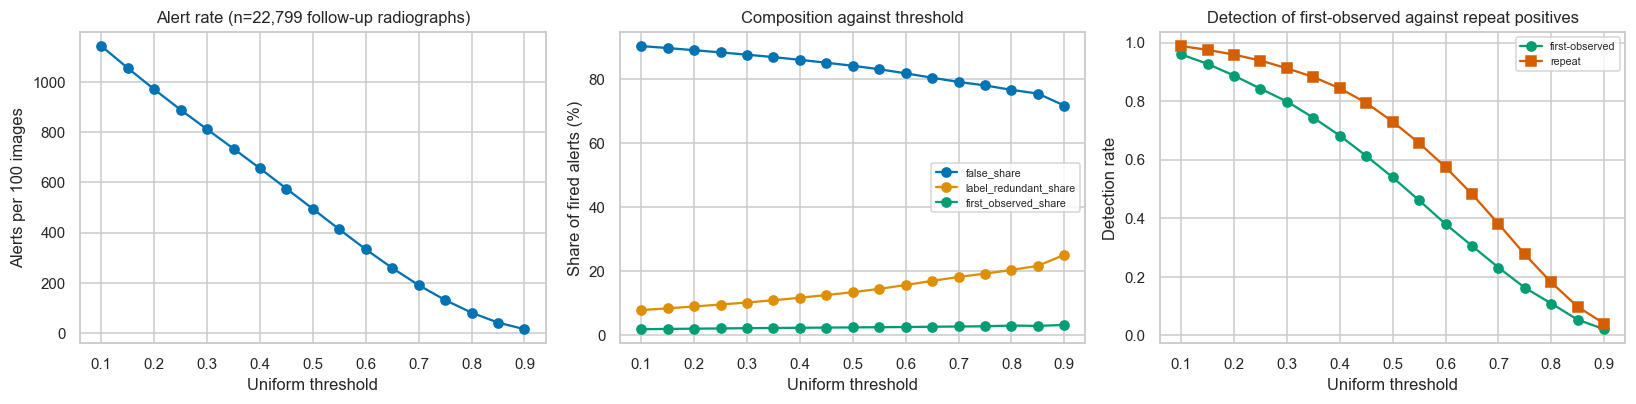

  figure -> fig04_firstobserved_vs_burden.png


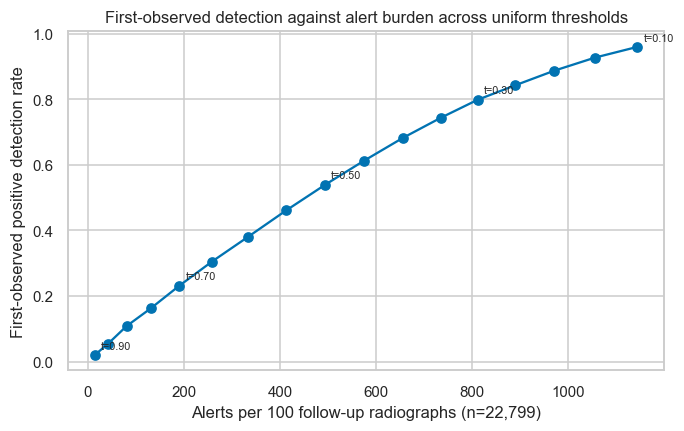

In [7]:
def recompute_prediction_history(d: pd.DataFrame, thresholds: Dict[str, float],
                                 delta: float = 0.10) -> pd.DataFrame:
    """Refire at new thresholds and rebuild prediction history within the test split."""
    x = d.copy()
    x["threshold"] = x["pathology"].map(thresholds).astype(float)
    x["model_fires"] = (x["probability"] >= x["threshold"]).astype("int8")
    x = x.sort_values(["Patient ID", "pathology", "sequence_position_ordinal",
                       "Image Index"], kind="mergesort")
    g = x.groupby(["Patient ID", "pathology"], observed=True, sort=False)["model_fires"]
    x["fired_prior_encounter"] = g.shift(1)
    x["fired_ever_prior"] = (g.cumsum() - x["model_fires"]) > 0
    return x


def operating_point_summary(d: pd.DataFrame, name: str,
                            thresholds: Dict[str, float]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Burden composition and per-pathology metrics at one operating point."""
    x = recompute_prediction_history(d, thresholds)
    x["alert_category"] = classify(x, PRIMARY_REDUNDANCY)
    x["alert_category_pred"] = classify(x, "prediction_historical")

    imgs = x["Image Index"].nunique()
    c = x["alert_category"].value_counts()
    cp = x["alert_category_pred"].value_counts()
    fired = int(sum(c.get(k, 0) for k in FIRED_CATEGORIES))
    correct = int(c.get("redundant_alert", 0) + c.get("first_observed_positive_alert", 0))
    per_img = (x[x["alert_category"].isin(FIRED_CATEGORIES)].groupby("Image Index").size()
               .reindex(x["Image Index"].unique(), fill_value=0))
    gp = detection_gap(x)
    fo = float(gp.loc[False, "sensitivity"]) if False in gp.index else np.nan
    rp = float(gp.loc[True, "sensitivity"]) if True in gp.index else np.nan
    pos_total = int((x["label_current"] == 1).sum())

    summ = pd.DataFrame([{
        "operating_point": name,
        "mean_threshold": round(float(np.mean(list(thresholds.values()))), 4),
        "fired_alerts": fired,
        "alerts_per_100_followup_images": round(100 * fired / imgs, 3),
        "mean_alerts_per_radiograph": round(float(per_img.mean()), 4),
        "pct_radiographs_with_at_least_one_alert": round(100 * float((per_img > 0).mean()), 3),
        "false_share_pct": round(100 * c.get("false_alert", 0) / fired, 3) if fired else np.nan,
        "label_redundant_share_pct": round(100 * c.get("redundant_alert", 0) / fired, 3)
        if fired else np.nan,
        "prediction_redundant_share_pct": round(100 * cp.get("redundant_alert", 0) / fired, 3)
        if fired else np.nan,
        "first_observed_share_pct":
            round(100 * c.get("first_observed_positive_alert", 0) / fired, 3)
            if fired else np.nan,
        "first_observed_share_of_correct_pct":
            round(100 * c.get("first_observed_positive_alert", 0) / correct, 3)
            if correct else np.nan,
        "missed_positive_fraction": round(c.get("missed_positive", 0) / pos_total, 4)
        if pos_total else np.nan,
        "sens_first_observed": round(fo, 4), "sens_repeat": round(rp, 4),
        "detection_gap_pp": round(100 * (rp - fo), 3),
    }])

    rows = []
    for p in PATHOLOGIES:
        s = x[x["pathology"] == p]
        y = (s["label_current"] == 1).to_numpy()
        f = (s["model_fires"] == 1).to_numpy()
        tp, fp = int((f & y).sum()), int((f & ~y).sum())
        rows.append({"operating_point": name, "pathology": p,
                     "threshold": thresholds[p], "n_opportunities": len(s),
                     "n_positive": int(y.sum()), "fired": int(f.sum()),
                     "sensitivity": round(tp / y.sum(), 4) if y.sum() else np.nan,
                     "ppv": round(tp / (tp + fp), 4) if (tp + fp) else np.nan,
                     "alert_rate": round(float(f.mean()), 4)})
    return summ, pd.DataFrame(rows)


# --- alternative sensitivity floor, recovered from the saved validation grid ---
ALT_THRESH: Optional[Dict[str, float]] = None
if {"pathology", "threshold", "sensitivity", "f1"} <= set(VAL_GRID.columns):
    alt = {}
    for p in PATHOLOGIES:
        g = VAL_GRID[VAL_GRID["pathology"] == p]
        ok = g[g["sensitivity"] >= ALT_SENSITIVITY_FLOOR]
        row = ok.loc[ok["f1"].idxmax()] if len(ok) and ok["f1"].notna().any() \
            else g.loc[g["sensitivity"].idxmax()]
        alt[p] = float(row["threshold"])
    ALT_THRESH = alt
    print(f"Alternative thresholds (validation sensitivity >= {ALT_SENSITIVITY_FLOOR}) "
          "recovered from the saved validation grid; no test data used.")
else:
    record_not_estimable("validation sensitivity>=0.80 operating point",
                         "validation_threshold_grid lacks required columns",
                         len(VAL_GRID), "grid with pathology/threshold/sensitivity/f1")

OP_POINTS: List[Tuple[str, Dict[str, float]]] = [("frozen_primary", THRESH_MAP)]
for t in FIXED_THRESHOLDS:
    OP_POINTS.append((f"fixed_{t:.2f}", {p: float(t) for p in PATHOLOGIES}))
if ALT_THRESH:
    OP_POINTS.append((f"validation_sens_floor_{ALT_SENSITIVITY_FLOOR:.2f}", ALT_THRESH))
for t in THRESHOLD_GRID:
    OP_POINTS.append((f"grid_{t:.2f}", {p: float(t) for p in PATHOLOGIES}))

with timed(f"threshold sensitivity ({len(OP_POINTS)} operating points)"):
    summ_rows, path_rows = [], []
    for name, tm in OP_POINTS:
        s, pr = operating_point_summary(PRIMARY, name, tm)
        summ_rows.append(s); path_rows.append(pr)
THRESH_SENS = pd.concat(summ_rows, ignore_index=True)
THRESH_PATH = pd.concat(path_rows, ignore_index=True)
save_table(THRESH_SENS, "part3_threshold_sensitivity")
save_table(THRESH_PATH, "part3_threshold_pathology_metrics")

_key = THRESH_SENS[~THRESH_SENS["operating_point"].str.startswith("grid_")]
print()
print(_key[["operating_point", "alerts_per_100_followup_images", "false_share_pct",
            "label_redundant_share_pct", "first_observed_share_pct",
            "first_observed_share_of_correct_pct", "detection_gap_pp"]].to_string(index=False))
print("\nThese are threshold sensitivity analyses. No operating point is preferred on the "
      "basis of any test quantity.")

grid = THRESH_SENS[THRESH_SENS["operating_point"].str.startswith("grid_")].copy()
grid["t"] = grid["operating_point"].str.replace("grid_", "").astype(float)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].plot(grid["t"], grid["alerts_per_100_followup_images"], marker="o", color=CB[0])
axes[0].set_xlabel("Uniform threshold"); axes[0].set_ylabel("Alerts per 100 images")
axes[0].set_title(f"Alert rate (n={n_img:,} follow-up radiographs)")
for i, k in enumerate(["false_share_pct", "label_redundant_share_pct",
                       "first_observed_share_pct"]):
    axes[1].plot(grid["t"], grid[k], marker="o", color=CB[i], label=k.replace("_pct", ""))
axes[1].set_xlabel("Uniform threshold"); axes[1].set_ylabel("Share of fired alerts (%)")
axes[1].set_title("Composition against threshold"); axes[1].legend(fontsize=7)
axes[2].plot(grid["t"], grid["sens_first_observed"], marker="o", color=CB[2],
             label="first-observed")
axes[2].plot(grid["t"], grid["sens_repeat"], marker="s", color=CB[3], label="repeat")
axes[2].set_xlabel("Uniform threshold"); axes[2].set_ylabel("Detection rate")
axes[2].set_title("Detection of first-observed against repeat positives")
axes[2].legend(fontsize=7)
fig.tight_layout()
save_figure(fig, "fig03_threshold_sensitivity")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid["alerts_per_100_followup_images"], grid["sens_first_observed"],
        marker="o", color=CB[0])
for _, r in grid.iterrows():
    if round(r["t"], 2) in (0.10, 0.30, 0.50, 0.70, 0.90):
        ax.annotate(f"t={r['t']:.2f}", (r["alerts_per_100_followup_images"],
                                        r["sens_first_observed"]),
                    fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel(f"Alerts per 100 follow-up radiographs (n={n_img:,})")
ax.set_ylabel("First-observed positive detection rate")
ax.set_title("First-observed detection against alert burden across uniform thresholds")
save_figure(fig, "fig04_firstobserved_vs_burden")
plt.show()

## 7. Redundancy-definition and sequence-history sensitivity analysis

### 7.1 Four predicates and the history mismatch

Two label-history and two prediction-history predicates, reported separately and never
combined. The mismatch table cross-tabulates prior positive label against prior model
fire for current-positive rows. A mismatch is exactly that: a discrepancy between the
available label history and the model's own alert history. It does not demonstrate a
memory failure, clinical redundancy, or a workflow error.

### 7.2 Within-episode analysis: the severity control

This is the analysis that decides whether the detection gap of section 4 stands.

An **episode** is a maximal run of consecutive positive labels for one patient and one
pathology within the test sequence. Within an episode of length two or more, detection at
the run's **first** appearance is compared against detection at its **later**
appearances. Patient and pathology are held constant, so between-patient severity and
between-finding conspicuity are removed by design. What remains is position within the run.

A residual confound survives even this: a finding may genuinely enlarge over an episode,
so later appearances could be more conspicuous for real clinical reasons rather than
because the model has "seen" them. This design cannot separate those, and the result must
be stated with that limit attached.

In [8]:
red_rows, reclass = [], []
for pred in REDUNDANCY_PREDICATES:
    cat = classify(PRIMARY, pred)
    c = cat.value_counts()
    fired = int(sum(c.get(k, 0) for k in FIRED_CATEGORIES))
    correct = int(c.get("redundant_alert", 0) + c.get("first_observed_positive_alert", 0))
    red_rows.append({
        "redundancy_definition": pred,
        "history_family": "label_history" if pred.startswith("label") else "prediction_history",
        "fired_alerts": fired,
        "false_share_pct": round(100 * c.get("false_alert", 0) / fired, 3),
        "redundant_share_pct": round(100 * c.get("redundant_alert", 0) / fired, 3),
        "first_observed_share_pct":
            round(100 * c.get("first_observed_positive_alert", 0) / fired, 3),
        "redundant_share_of_correct_pct": round(100 * c.get("redundant_alert", 0) / correct, 3)
        if correct else np.nan,
        "n_redundant": int(c.get("redundant_alert", 0)),
        "n_first_observed": int(c.get("first_observed_positive_alert", 0))})
RED_CMP = pd.DataFrame(red_rows)
save_table(RED_CMP, "part3_redundancy_definition_comparison")
print(RED_CMP.to_string(index=False))

for fam, hist, imm in (("label_history", "label_historical", "label_immediate_prior"),
                       ("prediction_history", "prediction_historical",
                        "prediction_immediate_prior")):
    a, b = classify(PRIMARY, hist), classify(PRIMARY, imm)
    ct = pd.crosstab(a, b)
    moved = int((a != b).sum())
    reclass.append({"history_family": fam, "historical_definition": hist,
                    "immediate_definition": imm, "rows_reclassified": moved,
                    "pct_reclassified": round(100 * moved / len(PRIMARY), 4)})
save_table(pd.DataFrame(reclass), "part3_redundancy_reclassification")

pos = PRIMARY[PRIMARY["label_current"] == 1].copy()
pos["prior_label"] = pos["label_ever_prior"].fillna(False).astype(bool)
pos["prior_fire"] = pos["fired_ever_prior"].fillna(False).astype(bool)
mis = (pos.groupby(["prior_label", "prior_fire"]).size()
       .rename("n").reset_index())
mis["pct_of_current_positive_rows"] = (100 * mis["n"] / len(pos)).round(3)
mis["cell"] = np.select(
    [(mis["prior_label"]) & (mis["prior_fire"]), (mis["prior_label"]) & (~mis["prior_fire"]),
     (~mis["prior_label"]) & (mis["prior_fire"])],
    ["prior_label_and_prior_fire", "prior_label_no_prior_fire",
     "no_prior_label_but_prior_fire"], default="neither")
mis_path = (pos.groupby(["pathology", "prior_label", "prior_fire"]).size()
            .rename("n").reset_index())
save_table(mis, "part3_label_prediction_history_mismatch")
save_table(mis_path, "part3_label_prediction_history_mismatch_by_pathology")
print(); print(mis[["cell", "n", "pct_of_current_positive_rows"]].to_string(index=False))
print("\nThis is a discrepancy between available label history and model-alert history. "
      "It is not evidence of a memory failure, clinical redundancy, or workflow error.")

  table  -> part3_redundancy_definition_comparison.csv  (4 x 9)
     redundancy_definition     history_family  fired_alerts  false_share_pct  redundant_share_pct  first_observed_share_pct  redundant_share_of_correct_pct  n_redundant  n_first_observed
          label_historical      label_history        158857            87.52               10.314                     2.165                          82.648        16385              3440
     label_immediate_prior      label_history        158857            87.52                5.353                     7.127                          42.890         8503             11322
     prediction_historical prediction_history        158857            87.52               12.054                     0.426                          96.585        19148               677
prediction_immediate_prior prediction_history        158857            87.52               10.377                     2.103                          83.153        16485              3340
 

           stratum  n_episodes  n_first_appearances  n_later_appearances  sens_first_in_episode  sens_later_in_episode  within_episode_gap_pp  gap_ci_lower  gap_ci_upper
           overall        5191                 5191                10229                 0.7844                 0.8074                  2.298         1.045         3.512
      Infiltration        1291                 1291                 2506                 0.9086                 0.9258                  1.718           NaN           NaN
          Effusion         975                  975                 2109                 0.6451                 0.7089                  6.374           NaN           NaN
       Atelectasis         653                  653                 1099                 0.8055                 0.8271                  2.160           NaN           NaN
            Nodule         273                  273                  445                 0.6484                 0.6360                 -1.240         

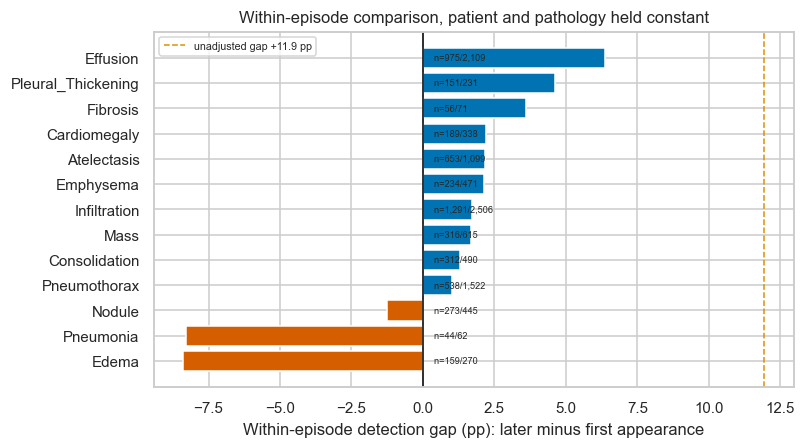

  figure -> fig06_redundancy_definitions.png


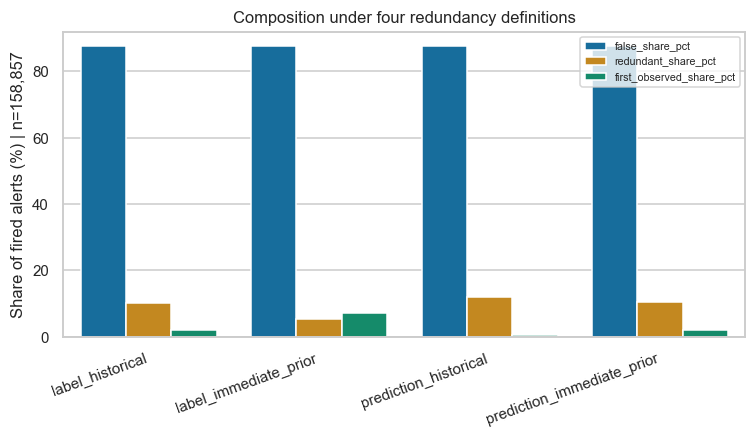

In [9]:
# --------------------- within-episode severity control ------------------------
def build_episodes(d: pd.DataFrame, min_len: int = MIN_EPISODE_LENGTH) -> pd.DataFrame:
    """Label maximal runs of consecutive positive labels per patient and pathology.

    Adds `episode_id`, `episode_length` and `position_in_episode` (1-based). Restricts to
    runs of at least `min_len` consecutive positives so that first and later appearances of
    the same finding in the same patient can be compared.
    """
    x = d[d["label_current"] == 1].copy()
    x = x.sort_values(["Patient ID", "pathology", "sequence_position_ordinal"],
                      kind="mergesort")
    key = ["Patient ID", "pathology"]
    seq = x["sequence_position_ordinal"]
    prev = x.groupby(key, observed=True)["sequence_position_ordinal"].shift(1)
    new_run = (prev.isna()) | ((seq - prev) != 1)
    x["episode_id"] = new_run.groupby([x[k] for k in key], observed=True).cumsum()
    grp = x.groupby(key + ["episode_id"], observed=True)
    x["episode_length"] = grp["sequence_position_ordinal"].transform("size")
    x["position_in_episode"] = grp.cumcount() + 1
    return x[x["episode_length"] >= min_len].copy()


EPI = build_episodes(PRIMARY)
if EPI.empty:
    record_not_estimable("within-episode severity control", "no episodes of length >= 2",
                         0, f"episodes with >= {MIN_EPISODE_LENGTH} consecutive positives")
    EPISODE_RESULT = pd.DataFrame(NOT_ESTIMABLE[-1:])
else:
    EPI["detected"] = EPI["model_fires"] == 1
    EPI["is_first_in_episode"] = EPI["position_in_episode"] == 1

    def episode_summary(d: pd.DataFrame, label: str) -> Dict[str, object]:
        g = d.groupby("is_first_in_episode")["detected"].agg(n="size", det="sum")
        first = g.loc[True] if True in g.index else pd.Series({"n": 0, "det": 0})
        later = g.loc[False] if False in g.index else pd.Series({"n": 0, "det": 0})
        sf = first["det"] / first["n"] if first["n"] else np.nan
        sl = later["det"] / later["n"] if later["n"] else np.nan
        n_ep = int(d.groupby(["Patient ID", "pathology", "episode_id"],
                             observed=True).ngroups)
        return {"stratum": label, "n_episodes": n_ep,
                "n_first_appearances": int(first["n"]),
                "n_later_appearances": int(later["n"]),
                "sens_first_in_episode": round(float(sf), 4),
                "sens_later_in_episode": round(float(sl), 4),
                "within_episode_gap_pp": round(100 * float(sl - sf), 3)}

    rows = [episode_summary(EPI, "overall")]
    for p in PATHOLOGIES:
        s = EPI[EPI["pathology"] == p]
        if len(s):
            rows.append(episode_summary(s, p))
    EPISODE_RESULT = pd.DataFrame(rows)

    # patient-clustered bootstrap on the within-episode gap
    epat = EPI.groupby("Patient ID").apply(
        lambda d: pd.Series({
            "n_first": int(d["is_first_in_episode"].sum()),
            "d_first": int((d["is_first_in_episode"] & d["detected"]).sum()),
            "n_later": int((~d["is_first_in_episode"]).sum()),
            "d_later": int((~d["is_first_in_episode"] & d["detected"]).sum())}),
        include_groups=False)
    arr = epat.to_numpy(); npt_e = len(arr)
    rng = np.random.default_rng(RANDOM_SEED)
    gaps = []
    for _ in range(N_BOOT):
        s = arr[rng.integers(0, npt_e, npt_e)].sum(axis=0)
        if s[0] and s[2]:
            gaps.append(100 * (s[3] / s[2] - s[1] / s[0]))
    gaps = np.asarray(gaps)
    point_gap = float(EPISODE_RESULT.loc[0, "within_episode_gap_pp"])
    EPISODE_RESULT.loc[0, "gap_ci_lower"] = round(float(np.percentile(gaps, 2.5)), 3)
    EPISODE_RESULT.loc[0, "gap_ci_upper"] = round(float(np.percentile(gaps, 97.5)), 3)

    print(EPISODE_RESULT.to_string(index=False))
    print(f"\nWithin-episode gap {point_gap:+.2f} pp "
          f"(95% CI {EPISODE_RESULT.loc[0,'gap_ci_lower']:+.2f} to "
          f"{EPISODE_RESULT.loc[0,'gap_ci_upper']:+.2f}), against the unadjusted "
          f"between-episode gap of {POINT['detection_gap_pp']:+.2f} pp.")
    print("Patient and pathology are held constant here, so between-patient severity and "
          "between-finding conspicuity are removed by design. Genuine enlargement of a "
          "finding across an episode is NOT removed and remains a limitation.")

save_table(EPISODE_RESULT, "part3_within_episode_severity_control")

if not EPI.empty:
    sub = EPISODE_RESULT[EPISODE_RESULT["stratum"] != "overall"].sort_values(
        "within_episode_gap_pp")
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    ax.barh(sub["stratum"], sub["within_episode_gap_pp"],
            color=[CB[3] if v < 0 else CB[0] for v in sub["within_episode_gap_pp"]])
    ax.axvline(0, color="black", lw=1)
    ax.axvline(POINT["detection_gap_pp"], color=CB[1], ls="--", lw=1,
               label=f"unadjusted gap {POINT['detection_gap_pp']:+.1f} pp")
    for y, (n1, n2) in enumerate(zip(sub["n_first_appearances"], sub["n_later_appearances"])):
        ax.text(0.2, y, f"  n={n1:,}/{n2:,}", va="center", fontsize=6)
    ax.set_xlabel("Within-episode detection gap (pp): later minus first appearance")
    ax.set_title("Within-episode comparison, patient and pathology held constant")
    ax.legend(fontsize=7)
    save_figure(fig, "fig05_within_episode_gap")
    plt.show()

fig, ax = plt.subplots(figsize=(8, 3.6))
m = RED_CMP.melt(id_vars="redundancy_definition",
                 value_vars=["false_share_pct", "redundant_share_pct",
                             "first_observed_share_pct"],
                 var_name="category", value_name="share")
sns.barplot(data=m, x="redundancy_definition", y="share", hue="category", ax=ax)
ax.set_xlabel(""); ax.set_ylabel(f"Share of fired alerts (%) | n={n_fired:,}")
ax.set_title("Composition under four redundancy definitions")
plt.xticks(rotation=20, ha="right"); ax.legend(fontsize=7)
save_figure(fig, "fig06_redundancy_definitions")
plt.show()

## 8. Cohort, pathology, projection, and age-integrity sensitivity analyses

Each restriction re-runs the frozen primary analysis on a subset. Differences describe
the subset, not a more valid population: a restricted cohort supports no generalisation
claim beyond itself.

The **validation discrimination floor** is included here rather than in Part 2 because
selecting labels on test AUROC would be selection on the outcome. The validation figure
carries no test information and is admissible.

  table  -> part3_cohort_sensitivity.csv  (11 x 19)
                              cohort  n_patients  fired_alerts  redundant_share_of_correct_pct  detection_gap_pp  inadequate_sample
                             primary        1424        158857                          82.648            11.948              False
               strict_history_cohort        1424        158857                          82.648            11.948              False
      exclude_nonzero_followup_start        1424        158857                          82.648            11.948              False
                exclude_internal_gap        1424        158857                          82.648            11.948              False
exclude_duplicate_or_uncertain_order        1424        158857                          82.648            11.948              False
               age_consistent_cohort        1226        126359                          82.210            11.937              False
                  projec

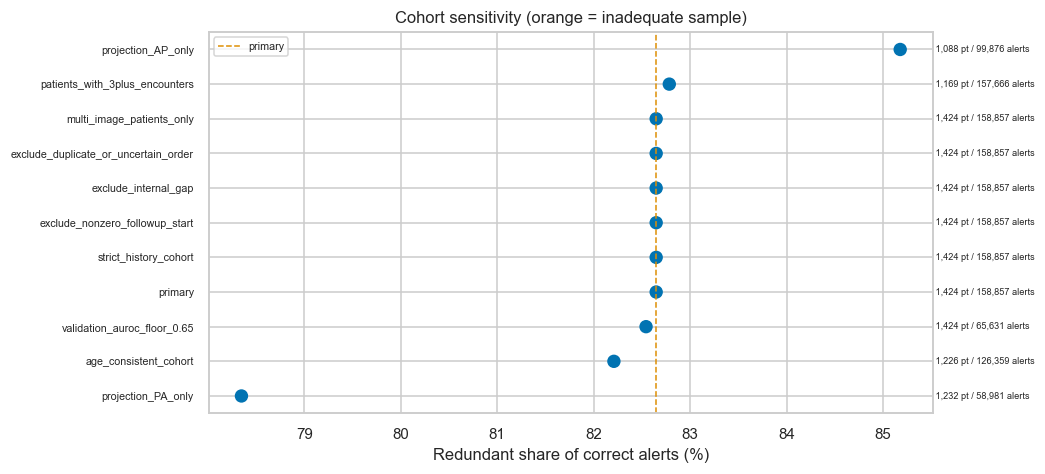

In [10]:
_flag_cols = [c for c in ["followup_starts_at_zero", "followup_internal_gap_present",
                          "duplicate_patient_followup", "sequence_order_uncertain",
                          "patient_sequence_length"] if c in P1_WIDE.columns]
COHORT_BASE = PRIMARY.merge(P1_WIDE[["Image Index"] + _flag_cols].drop_duplicates(),
                            on="Image Index", how="left", suffixes=("", "_p1"))

_val_auroc = dict(zip(VAL_METRICS["pathology"], VAL_METRICS["auroc"])) \
    if "auroc" in VAL_METRICS.columns else {}
_floor_labels = [p for p in PATHOLOGIES
                 if pd.notna(_val_auroc.get(p, np.nan))
                 and _val_auroc[p] >= VALIDATION_AUROC_FLOOR]

RESTRICTIONS: List[Tuple[str, Callable[[pd.DataFrame], pd.Series]]] = [
    ("primary", lambda d: pd.Series(True, index=d.index)),
    ("strict_history_cohort", lambda d: d["strict_history_eligible"].astype(bool)),
    ("exclude_nonzero_followup_start",
     lambda d: d.get("followup_starts_at_zero", pd.Series(True, index=d.index)).fillna(True).astype(bool)),
    ("exclude_internal_gap",
     lambda d: ~d.get("followup_internal_gap_present", pd.Series(False, index=d.index)).fillna(False).astype(bool)),
    ("exclude_duplicate_or_uncertain_order",
     lambda d: ~(d.get("duplicate_patient_followup", pd.Series(False, index=d.index)).fillna(False).astype(bool)
                 | d.get("sequence_order_uncertain", pd.Series(False, index=d.index)).fillna(False).astype(bool))),
    ("age_consistent_cohort", lambda d: d["age_consistent"].astype(bool)),
    ("projection_PA_only", lambda d: d["projection_group"].astype(str) == "PA"),
    ("projection_AP_only", lambda d: d["projection_group"].astype(str) == "AP"),
    ("multi_image_patients_only",
     lambda d: d.get("patient_sequence_length", pd.Series(99, index=d.index)).fillna(99) > 1),
    ("patients_with_3plus_encounters",
     lambda d: d.get("patient_sequence_length", pd.Series(99, index=d.index)).fillna(99) >= 3),
    (f"validation_auroc_floor_{VALIDATION_AUROC_FLOOR}",
     lambda d: d["pathology"].isin(_floor_labels)),
]

MIN_COHORT_PATIENTS, MIN_COHORT_FIRED = 100, 500
rows = []
for name, fn in RESTRICTIONS:
    sub = COHORT_BASE[fn(COHORT_BASE)]
    if sub.empty:
        record_not_estimable(f"cohort sensitivity: {name}", "empty cohort", 0, "n > 0")
        continue
    c = sub["alert_category"].value_counts()
    fired = int(sum(c.get(k, 0) for k in FIRED_CATEGORIES))
    correct = int(c.get("redundant_alert", 0) + c.get("first_observed_positive_alert", 0))
    gpp = detection_gap(sub)
    rows.append({
        "cohort": name, "n_patients": sub["Patient ID"].nunique(),
        "n_images": sub["Image Index"].nunique(), "n_opportunities": len(sub),
        "n_positive_labels": int((sub["label_current"] == 1).sum()),
        "fired_alerts": fired,
        "alerts_per_100_images": round(100 * fired / sub["Image Index"].nunique(), 3),
        "false_share_pct": round(100 * c.get("false_alert", 0) / fired, 3) if fired else np.nan,
        "redundant_share_pct": round(100 * c.get("redundant_alert", 0) / fired, 3) if fired else np.nan,
        "first_observed_share_pct":
            round(100 * c.get("first_observed_positive_alert", 0) / fired, 3) if fired else np.nan,
        "redundant_share_of_correct_pct":
            round(100 * c.get("redundant_alert", 0) / correct, 3) if correct else np.nan,
        "detection_gap_pp": round(100 * (float(gpp.loc[True, "sensitivity"])
                                         - float(gpp.loc[False, "sensitivity"])), 3)
        if {True, False} <= set(gpp.index) else np.nan,
        "inadequate_sample": (sub["Patient ID"].nunique() < MIN_COHORT_PATIENTS
                              or fired < MIN_COHORT_FIRED)})
COHORT_SENS = pd.DataFrame(rows)
base = COHORT_SENS[COHORT_SENS["cohort"] == "primary"].iloc[0]
for k in ("redundant_share_of_correct_pct", "detection_gap_pp", "alerts_per_100_images"):
    COHORT_SENS[f"{k}_abs_change_vs_primary"] = (COHORT_SENS[k] - base[k]).round(3)
    COHORT_SENS[f"{k}_rel_change_pct"] = (
        100 * (COHORT_SENS[k] - base[k]) / base[k]).round(3)
save_table(COHORT_SENS, "part3_cohort_sensitivity")
print(COHORT_SENS[["cohort", "n_patients", "fired_alerts", "redundant_share_of_correct_pct",
                   "detection_gap_pp", "inadequate_sample"]].to_string(index=False))
print(f"\nValidation AUROC floor {VALIDATION_AUROC_FLOOR} retains "
      f"{len(_floor_labels)} of {len(PATHOLOGIES)} labels: {_floor_labels}")
print("Restricted-cohort differences describe those subsets only.")

fig, ax = plt.subplots(figsize=(8.5, 4.5))
cs = COHORT_SENS.sort_values("redundant_share_of_correct_pct")
ax.scatter(cs["redundant_share_of_correct_pct"], range(len(cs)),
           c=[CB[3] if u else CB[0] for u in cs["inadequate_sample"]], s=60)
ax.axvline(base["redundant_share_of_correct_pct"], color=CB[1], ls="--", lw=1,
           label="primary")
ax.set_yticks(range(len(cs))); ax.set_yticklabels(cs["cohort"], fontsize=7)
for y, (n, f) in enumerate(zip(cs["n_patients"], cs["fired_alerts"])):
    ax.text(ax.get_xlim()[1], y, f" {n:,} pt / {f:,} alerts", fontsize=6, va="center")
ax.set_xlabel("Redundant share of correct alerts (%)")
ax.set_title("Cohort sensitivity (orange = inadequate sample)")
ax.legend(fontsize=7)
save_figure(fig, "fig07_cohort_sensitivity")
plt.show()

  table  -> part3_pathology_level_results.csv  (13 x 21)
  table  -> part3_pathology_bootstrap_ci.csv  (13 x 7)
  table  -> part3_macro_micro_summary.csv  (4 x 3)

         pathology  n_positive  fired_alerts  false_share_pct  redundant_share_of_correct_pct  ci_eligible
      Infiltration        5887         18632           71.828                          89.769         True
          Effusion        4520          8984           67.932                          89.552         True
       Atelectasis        3122         14356           82.850                          81.560         True
            Nodule        1465         10669           91.827                          76.720         True
              Mass        1582         11283           91.031                          85.573         True
     Consolidation        1768         18090           90.818                          74.232         True
      Pneumothorax        2633         14572           84.299                          

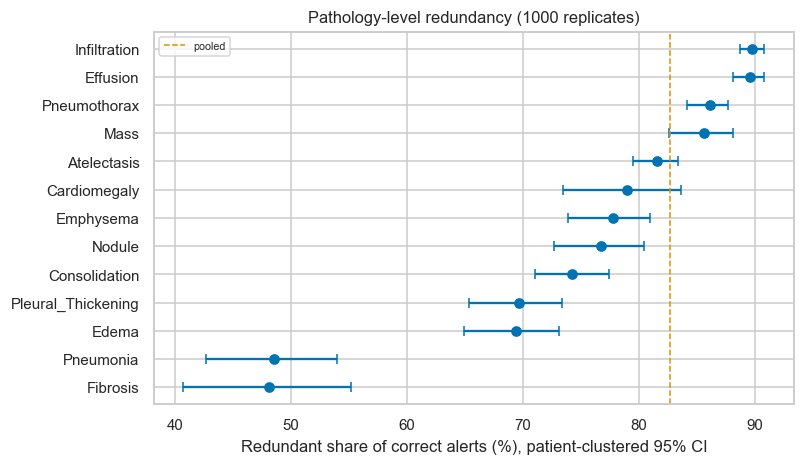

In [11]:
# ------------------------ pathology-level results -----------------------------
p2m = TEST_METRICS.set_index("pathology")
rows = []
for p in PATHOLOGIES:
    s = PRIMARY[PRIMARY["pathology"] == p]
    c = s["alert_category"].value_counts()
    fired = int(sum(c.get(k, 0) for k in FIRED_CATEGORIES))
    correct = int(c.get("redundant_alert", 0) + c.get("first_observed_positive_alert", 0))
    npos, npt_p = int((s["label_current"] == 1).sum()), s["Patient ID"].nunique()
    rows.append({
        "pathology": p, "test_prevalence_pct": round(100 * float(p2m.loc[p, "prevalence_pct"]) / 100 * 100, 4)
        if "prevalence_pct" in p2m.columns else np.nan,
        "selected_threshold": THRESH_MAP[p],
        "auroc": float(p2m.loc[p, "auroc"]) if "auroc" in p2m.columns else np.nan,
        "auprc": float(p2m.loc[p, "auprc"]) if "auprc" in p2m.columns else np.nan,
        "sensitivity_at_threshold": float(p2m.loc[p, "sel_sensitivity"])
        if "sel_sensitivity" in p2m.columns else np.nan,
        "ppv_at_threshold": float(p2m.loc[p, "sel_ppv"]) if "sel_ppv" in p2m.columns else np.nan,
        "n_followup_opportunities": len(s), "n_positive": npos, "n_patients": npt_p,
        "fired_alerts": fired,
        "alerts_per_100_images": round(100 * fired / s["Image Index"].nunique(), 3),
        "n_false": int(c.get("false_alert", 0)),
        "false_share_pct": round(100 * c.get("false_alert", 0) / fired, 3) if fired else np.nan,
        "n_redundant": int(c.get("redundant_alert", 0)),
        "redundant_share_pct": round(100 * c.get("redundant_alert", 0) / fired, 3) if fired else np.nan,
        "redundant_share_of_correct_pct":
            round(100 * c.get("redundant_alert", 0) / correct, 3) if correct else np.nan,
        "n_first_observed": int(c.get("first_observed_positive_alert", 0)),
        "first_observed_share_pct":
            round(100 * c.get("first_observed_positive_alert", 0) / fired, 3) if fired else np.nan,
        "n_missed_positive": int(c.get("missed_positive", 0)),
        "ci_eligible": (fired >= MIN_PATHOLOGY_FIRED_ALERTS_FOR_CI
                        and npos >= MIN_PATHOLOGY_POSITIVES_FOR_CI
                        and npt_p >= MIN_PATHOLOGY_PATIENTS_FOR_CI)})
PATH_RESULTS = pd.DataFrame(rows)
save_table(PATH_RESULTS, "part3_pathology_level_results")

boot_rows = []
rng = np.random.default_rng(RANDOM_SEED + 7)
for p in PATHOLOGIES:
    r = PATH_RESULTS[PATH_RESULTS["pathology"] == p].iloc[0]
    if not r["ci_eligible"]:
        boot_rows.append({"pathology": p, "metric": "redundant_share_of_correct_pct",
                          "point_estimate": r["redundant_share_of_correct_pct"],
                          "ci_lower": np.nan, "ci_upper": np.nan, "ci_estimable": False,
                          "reason": "below minimum count rule"})
        continue
    s = PRIMARY[PRIMARY["pathology"] == p]
    pa = s.groupby("Patient ID").apply(lambda d: pd.Series({
        "red": int((d["alert_category"] == "redundant_alert").sum()),
        "fo": int((d["alert_category"] == "first_observed_positive_alert").sum())}),
        include_groups=False).to_numpy()
    draws = []
    for _ in range(N_BOOT):
        t = pa[rng.integers(0, len(pa), len(pa))].sum(axis=0)
        if t.sum():
            draws.append(100 * t[0] / t.sum())
    boot_rows.append({"pathology": p, "metric": "redundant_share_of_correct_pct",
                      "point_estimate": r["redundant_share_of_correct_pct"],
                      "ci_lower": round(float(np.percentile(draws, 2.5)), 3),
                      "ci_upper": round(float(np.percentile(draws, 97.5)), 3),
                      "ci_estimable": True, "reason": ""})
PATH_CI = pd.DataFrame(boot_rows)
save_table(PATH_CI, "part3_pathology_bootstrap_ci")

macro = PATH_RESULTS[["false_share_pct", "redundant_share_pct", "first_observed_share_pct",
                      "redundant_share_of_correct_pct"]].mean().round(3)
micro = pd.Series({
    "false_share_pct": 100 * counts.get("false_alert", 0) / n_fired,
    "redundant_share_pct": 100 * counts.get("redundant_alert", 0) / n_fired,
    "first_observed_share_pct": 100 * counts.get("first_observed_positive_alert", 0) / n_fired,
    "redundant_share_of_correct_pct": 100 * counts.get("redundant_alert", 0) / n_correct}).round(3)
save_table(pd.DataFrame({"macro_mean_over_pathologies": macro, "micro_pooled": micro}
                        ).reset_index().rename(columns={"index": "metric"}),
           "part3_macro_micro_summary")
print()
print(PATH_RESULTS[["pathology", "n_positive", "fired_alerts", "false_share_pct",
                    "redundant_share_of_correct_pct", "ci_eligible"]].to_string(index=False))
print(f"\nMacro mean over pathologies vs micro pooled:\n"
      f"{pd.DataFrame({'macro': macro, 'micro': micro}).to_string()}")
print("Macro and micro differ because Infiltration supplies a large share of all "
      "opportunities. Neither is reported alone.")

pc = PATH_CI[PATH_CI["ci_estimable"]].sort_values("point_estimate")
if len(pc):
    fig, ax = plt.subplots(figsize=(7.5, 4.4))
    y = np.arange(len(pc))
    ax.errorbar(pc["point_estimate"], y,
                xerr=[pc["point_estimate"] - pc["ci_lower"],
                      pc["ci_upper"] - pc["point_estimate"]],
                fmt="o", color=CB[0], capsize=3)
    ax.axvline(micro["redundant_share_of_correct_pct"], color=CB[1], ls="--", lw=1,
               label="pooled")
    ax.set_yticks(y); ax.set_yticklabels(pc["pathology"])
    ax.set_xlabel("Redundant share of correct alerts (%), patient-clustered 95% CI")
    ax.set_title(f"Pathology-level redundancy ({N_BOOT} replicates)")
    ax.legend(fontsize=7)
    save_figure(fig, "fig08_pathology_forest")
    plt.show()

## 9. Within-dataset adjudicated-label reference sensitivity analysis

The NIH-Google adjudicated labels are a **relabelling of ChestX-ray14 images by
radiologists**. They are not an external dataset and cannot support any claim about
external validation or transportability. This section is a restricted within-dataset
label-reference sensitivity analysis and is named as such throughout.

The file schema is discovered rather than assumed, mappings are created only where the
raw field definitions support them, and an unmappable schema produces a clear
not-estimable record instead of a forced analysis.

In [12]:
def discover_google_label_files(root: Path) -> List[Path]:
    """Locate candidate adjudicated-label files locally. No downloads."""
    pats = ["*google*label*.csv", "*google*label*.csv.gz", "*google*.csv", "*google*.csv.gz",
            "*adjudicat*.csv", "*adjudicat*.csv.gz"]
    hits: List[Path] = []
    for p in pats:
        hits += [f for f in Path(root).rglob(p) if f.is_file()]
    return sorted(set(hits))


def load_google_adjudicated_labels(path: Path) -> pd.DataFrame:
    return pd.read_csv(path)


def normalize_google_label_schema(df: pd.DataFrame) -> pd.DataFrame:
    """Normalise column names and coerce YES/NO style values to 0/1 where unambiguous."""
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]
    idcol = next((c for c in out.columns
                  if c.lower().replace(" ", "_") in
                  ("image_index", "imageindex", "image", "image_id", "filename")), None)
    if idcol and idcol != "Image Index":
        out = out.rename(columns={idcol: "Image Index"})
    for c in out.columns:
        if c == "Image Index":
            continue
        v = out[c].astype(str).str.strip().str.upper()
        if v.isin(["YES", "NO", "1", "0", "TRUE", "FALSE", "NAN", ""]).mean() > 0.95:
            out[c] = v.isin(["YES", "1", "TRUE"]).astype("int8")
    return out


GFILES = discover_google_label_files(GOOGLE_LABELS_DIR)
GOOGLE_OK = False
schema_rows: List[Dict[str, object]] = []
if not GFILES:
    record_not_estimable("adjudicated-label reference", "no candidate file found locally",
                         0, f"a Google adjudicated label file under {GOOGLE_LABELS_DIR}")
else:
    GPATH = GFILES[0]
    print(f"Adjudicated-label file: {GPATH.name}"
          + (f"  (others: {[f.name for f in GFILES[1:]]})" if len(GFILES) > 1 else ""))
    GRAW = normalize_google_label_schema(load_google_adjudicated_labels(GPATH))
    for c in GRAW.columns:
        schema_rows.append({"file": GPATH.name, "column": c, "dtype": str(GRAW[c].dtype),
                            "n_unique": int(GRAW[c].nunique()),
                            "example_values": str(list(GRAW[c].dropna().unique()[:4]))})
    GOOGLE_OK = "Image Index" in GRAW.columns
    if not GOOGLE_OK:
        record_not_estimable("adjudicated-label reference",
                             "no image identifier column found after normalisation",
                             len(GRAW), "an 'Image Index' style column")
save_table(pd.DataFrame(schema_rows) if schema_rows else
           pd.DataFrame([{"file": "none", "column": "none", "note": "no file discovered"}]),
           "part3_google_label_schema_audit")

MAPPING: List[Dict[str, object]] = []
if GOOGLE_OK:
    cols = {c.lower(): c for c in GRAW.columns if c != "Image Index"}

    def find(*keys) -> Optional[str]:
        for lc, orig in cols.items():
            if all(k in lc for k in keys):
                return orig
        return None

    cand = [
        ("Pneumothorax", find("pneumothorax"), ["Pneumothorax"], "direct",
         "adjudicated pneumothorax maps directly to the NIH pneumothorax label"),
        ("Nodule_or_mass", find("nodule"), ["Nodule", "Mass"], "union",
         "adjudicated nodule/mass is a single field; compared against the union of the "
         "NIH Nodule and Mass labels"),
        ("Airspace_opacity", find("opacity"),
         ["Infiltration", "Consolidation", "Edema", "Pneumonia"], "broad_phenotype",
         "adjudicated airspace opacity is a BROAD phenotype, not equivalent to any single "
         "NIH label; treated as a broad-phenotype sensitivity only"),
        ("Fracture", find("fracture"), [], "no_model_output",
         "no aligned model output; excluded"),
    ]
    for name, gcol, nih, kind, note in cand:
        usable = bool(gcol) and bool(nih) and all(p in PATHOLOGIES for p in nih)
        MAPPING.append({"adjudicated_field": name, "source_column": gcol,
                        "nih_labels": "|".join(nih), "mapping_type": kind,
                        "usable": usable, "rationale": note})
MAP_DF = pd.DataFrame(MAPPING) if MAPPING else pd.DataFrame(
    [{"adjudicated_field": "none", "usable": False, "rationale": "no schema available"}])
save_table(MAP_DF, "part3_google_mapping_table")
if len(MAP_DF):
    print(); print(MAP_DF.to_string(index=False))

Adjudicated-label file: google2019_nih-chest-xray-labels.csv.gz
  table  -> part3_google_label_schema_audit.csv  (16 x 5)
  table  -> part3_google_mapping_table.csv  (4 x 6)

adjudicated_field    source_column                                 nih_labels    mapping_type  usable                                                                                                                                rationale
     Pneumothorax     Pneumothorax                               Pneumothorax          direct    True                                                                     adjudicated pneumothorax maps directly to the NIH pneumothorax label
   Nodule_or_mass   Nodule or mass                                Nodule|Mass           union    True                                  adjudicated nodule/mass is a single field; compared against the union of the NIH Nodule and Mass labels
 Airspace_opacity Airspace opacity Infiltration|Consolidation|Edema|Pneumonia broad_phenotype    True adjudi

  table  -> part3_google_overlap_audit.csv  (1 x 5)

 adjudicated_rows_total  overlap_with_test_images  pct_of_test_images  overlap_patients  pct_of_test_patients
                   4376                      1962               7.665               860                30.747

Longitudinal adjudicated coverage: 23 of 1,424 primary-cohort patients have adjudicated labels on every encounter (1.62%).
Serial redundancy under the adjudicated reference is NOT estimable. This section is restricted to image-level label-reference sensitivity.
  table  -> part3_google_label_agreement.csv  (3 x 13)
  table  -> part3_google_model_reference_sensitivity.csv  (6 x 10)

adjudicated_field    mapping_type  n_images  adjudicated_prevalence_pct  nih_prevalence_pct  both_positive  nih_only  adjudicated_only  both_negative  raw_agreement  cohens_kappa  positive_agreement  negative_agreement
     Pneumothorax          direct      1962                       9.939              10.194             97       103      

C:\Users\kruta\AppData\Local\Temp\ipykernel_6124\529630617.py:95: UserWarning: NOT ESTIMABLE: adjudicated serial redundancy analysis - too few patients have adjudicated labels on every encounter, so within-sequence history cannot be rebuilt under the adjudicated reference
  warnings.warn(f"NOT ESTIMABLE: {analysis} - {reason}", UserWarning)


  figure -> fig09_adjudicated_reference.png


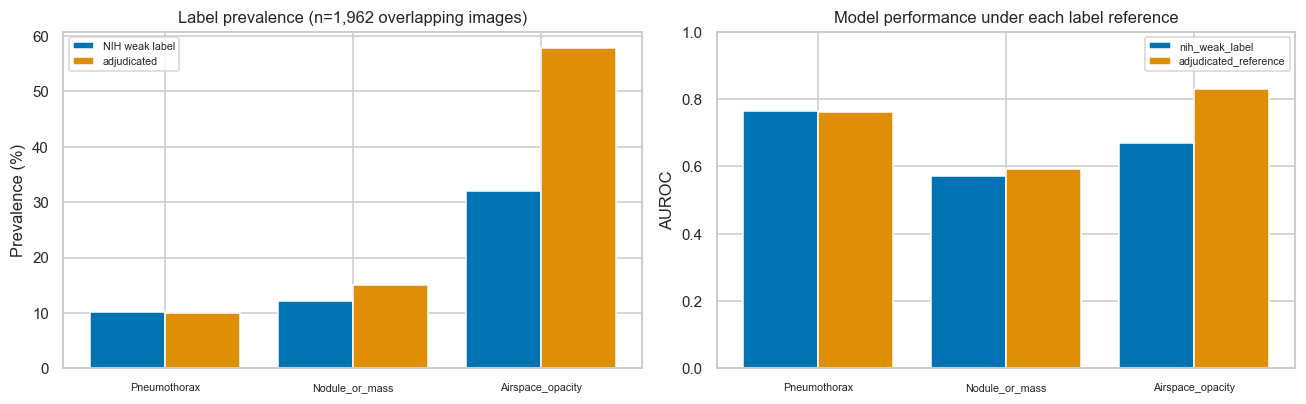

In [13]:
overlap_rows, agree_rows, ref_rows = [], [], []
USABLE = MAP_DF[MAP_DF.get("usable", False) == True] if len(MAP_DF) else pd.DataFrame()

if GOOGLE_OK and len(USABLE):
    test_imgs = set(PRED["Image Index"])
    g = GRAW[GRAW["Image Index"].isin(test_imgs)].drop_duplicates("Image Index")
    pt_of = PRED.drop_duplicates("Image Index").set_index("Image Index")["Patient ID"]
    overlap_rows.append({
        "adjudicated_rows_total": len(GRAW),
        "overlap_with_test_images": len(g),
        "pct_of_test_images": round(100 * len(g) / PRED["Image Index"].nunique(), 3),
        "overlap_patients": int(pt_of.reindex(g["Image Index"]).nunique()),
        "pct_of_test_patients": round(
            100 * pt_of.reindex(g["Image Index"]).nunique() / PRED["Patient ID"].nunique(), 3)})
    save_table(pd.DataFrame(overlap_rows), "part3_google_overlap_audit")
    print(); print(pd.DataFrame(overlap_rows).to_string(index=False))

    from sklearn.metrics import cohen_kappa_score, roc_auc_score, average_precision_score
    wide_lab = PRED.pivot_table(index="Image Index", columns="pathology",
                                values="label_current", aggfunc="first")
    wide_prob = PRED.pivot_table(index="Image Index", columns="pathology",
                                 values="probability", aggfunc="first")

    for _, m in USABLE.iterrows():
        nih = m["nih_labels"].split("|")
        gcol = m["source_column"]
        idx = g["Image Index"]
        ref = g.set_index("Image Index")[gcol].reindex(idx).astype(float)
        nih_lab = wide_lab.reindex(idx)[nih].max(axis=1)
        keep = ref.notna() & nih_lab.notna()
        ref_v, nih_v = ref[keep].astype(int).to_numpy(), nih_lab[keep].astype(int).to_numpy()
        if len(ref_v) < 50 or len(np.unique(ref_v)) < 2:
            record_not_estimable(f"adjudicated agreement: {m['adjudicated_field']}",
                                 "insufficient overlap or single class", len(ref_v),
                                 ">=50 images with both labels and both classes present")
            continue
        tp = int(((ref_v == 1) & (nih_v == 1)).sum()); fp = int(((ref_v == 0) & (nih_v == 1)).sum())
        fn = int(((ref_v == 1) & (nih_v == 0)).sum()); tn = int(((ref_v == 0) & (nih_v == 0)).sum())
        agree_rows.append({
            "adjudicated_field": m["adjudicated_field"], "mapping_type": m["mapping_type"],
            "n_images": len(ref_v), "adjudicated_prevalence_pct": round(100 * ref_v.mean(), 3),
            "nih_prevalence_pct": round(100 * nih_v.mean(), 3),
            "both_positive": tp, "nih_only": fp, "adjudicated_only": fn, "both_negative": tn,
            "raw_agreement": round((tp + tn) / len(ref_v), 4),
            "cohens_kappa": round(float(cohen_kappa_score(ref_v, nih_v)), 4),
            "positive_agreement": round(2 * tp / (2 * tp + fp + fn), 4) if (2*tp+fp+fn) else np.nan,
            "negative_agreement": round(2 * tn / (2 * tn + fp + fn), 4) if (2*tn+fp+fn) else np.nan})

        prob = wide_prob.reindex(idx)[nih].max(axis=1)[keep].to_numpy()
        thr = float(np.mean([THRESH_MAP[p] for p in nih]))
        fires = prob >= thr
        for refname, y in (("nih_weak_label", nih_v), ("adjudicated_reference", ref_v)):
            t_p = int((fires & (y == 1)).sum()); f_p = int((fires & (y == 0)).sum())
            ref_rows.append({
                "adjudicated_field": m["adjudicated_field"], "reference": refname,
                "n_images": len(y), "n_positive": int(y.sum()), "threshold_used": round(thr, 3),
                "auroc": round(float(roc_auc_score(y, prob)), 4) if len(np.unique(y)) > 1 else np.nan,
                "auprc": round(float(average_precision_score(y, prob)), 4) if y.sum() else np.nan,
                "sensitivity": round(t_p / y.sum(), 4) if y.sum() else np.nan,
                "ppv": round(t_p / (t_p + f_p), 4) if (t_p + f_p) else np.nan,
                "false_alert_proportion": round(f_p / (t_p + f_p), 4) if (t_p + f_p) else np.nan})

    # serial coverage: is longitudinal adjudicated history dense enough?
    cov = (PRIMARY.assign(has_adj=PRIMARY["Image Index"].isin(set(g["Image Index"])))
           .groupby("Patient ID")["has_adj"].mean())
    dense = int((cov >= 0.999).sum())
    print(f"\nLongitudinal adjudicated coverage: {dense:,} of {len(cov):,} primary-cohort "
          f"patients have adjudicated labels on every encounter "
          f"({100*dense/max(len(cov),1):.2f}%).")
    if dense < 100:
        record_not_estimable("adjudicated serial redundancy analysis",
                             "too few patients have adjudicated labels on every encounter, "
                             "so within-sequence history cannot be rebuilt under the "
                             "adjudicated reference", dense,
                             ">=100 patients with complete adjudicated sequence coverage")
        print("Serial redundancy under the adjudicated reference is NOT estimable. "
              "This section is restricted to image-level label-reference sensitivity.")

save_table(pd.DataFrame(agree_rows) if agree_rows else
           pd.DataFrame([{"status": "not_estimable",
                          "reason": "no usable mapping with sufficient overlap"}]),
           "part3_google_label_agreement")
save_table(pd.DataFrame(ref_rows) if ref_rows else
           pd.DataFrame([{"status": "not_estimable",
                          "reason": "no usable mapping with sufficient overlap"}]),
           "part3_google_model_reference_sensitivity")
if not overlap_rows:
    save_table(pd.DataFrame([{"status": "not_estimable",
                              "reason": "adjudicated labels unavailable or unmappable"}]),
               "part3_google_overlap_audit")

if agree_rows:
    print(); print(pd.DataFrame(agree_rows).to_string(index=False))
    print(); print(pd.DataFrame(ref_rows).to_string(index=False))
    print("\nThis is a within-dataset adjudicated-label reference sensitivity analysis. "
          "It is not external validation, and the adjudicated labels are not complete "
          "ground truth.")
    ag = pd.DataFrame(agree_rows)
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    x = np.arange(len(ag))
    axes[0].bar(x - 0.2, ag["nih_prevalence_pct"], 0.4, label="NIH weak label", color=CB[0])
    axes[0].bar(x + 0.2, ag["adjudicated_prevalence_pct"], 0.4, label="adjudicated", color=CB[1])
    axes[0].set_xticks(x); axes[0].set_xticklabels(ag["adjudicated_field"], fontsize=7)
    axes[0].set_ylabel("Prevalence (%)")
    axes[0].set_title(f"Label prevalence (n={ag['n_images'].iloc[0]:,} overlapping images)")
    axes[0].legend(fontsize=7)
    rf = pd.DataFrame(ref_rows)
    for i, ref in enumerate(["nih_weak_label", "adjudicated_reference"]):
        s = rf[rf["reference"] == ref]
        axes[1].bar(np.arange(len(s)) + (i - 0.5) * 0.4, s["auroc"], 0.4,
                    label=ref, color=CB[i])
    axes[1].set_xticks(np.arange(len(ag))); axes[1].set_xticklabels(ag["adjudicated_field"], fontsize=7)
    axes[1].set_ylabel("AUROC"); axes[1].set_ylim(0, 1)
    axes[1].set_title("Model performance under each label reference")
    axes[1].legend(fontsize=7)
    fig.tight_layout()
    save_figure(fig, "fig09_adjudicated_reference")
    plt.show()
else:
    print("\nAdjudicated-label analysis not estimable; not-estimable records written.")

## 10. Policy trade-off, retention, and descriptive dominance analysis

The five frozen Part 2 policies, on the same frozen stream, with patient-clustered
intervals from section 5.

**On the label-history oracle.** It is a retrospective benchmark estimating the effect of
suppressing alerts for label-positive findings previously observed in the available
sequence. It is not deployable as specified. It is also **not a universal upper bound**
on what prediction-history policies can achieve: a prediction-history policy can suppress
alerts the oracle retains, so the two trace different trade-off curves rather than one
bounding the other. Read it as a reference point.

**Descriptive dominance.** Policy A is descriptively dominated by policy B when B has at
least as large an alert reduction, at least as large a first-observed retention, and is
strictly better on one of the two. This is an operational trade-off comparison only. A
non-dominated policy is not thereby safe, optimal, clinically superior or deployable.

  table  -> part3_policy_tradeoff_and_dominance.csv  (5 x 20)
                                           policy                                        status  alerts_per_100_followup_images  pct_reduction_vs_baseline pct_reduction_ci  first_observed_positive_alert_retention_pct     retention_ci  descriptively_dominated
                                         baseline                                     reference                         696.772                      0.000     0.00 to 0.00                                      100.000 100.00 to 100.00                     True
                        prediction_one_alert_ever                              deployable_style                          35.164                     94.953   94.54 to 95.32                                       14.012   12.80 to 15.26                    False
prediction_immediate_repeat_or_threshold_crossing                              deployable_style                         176.894                     74.612   73.8

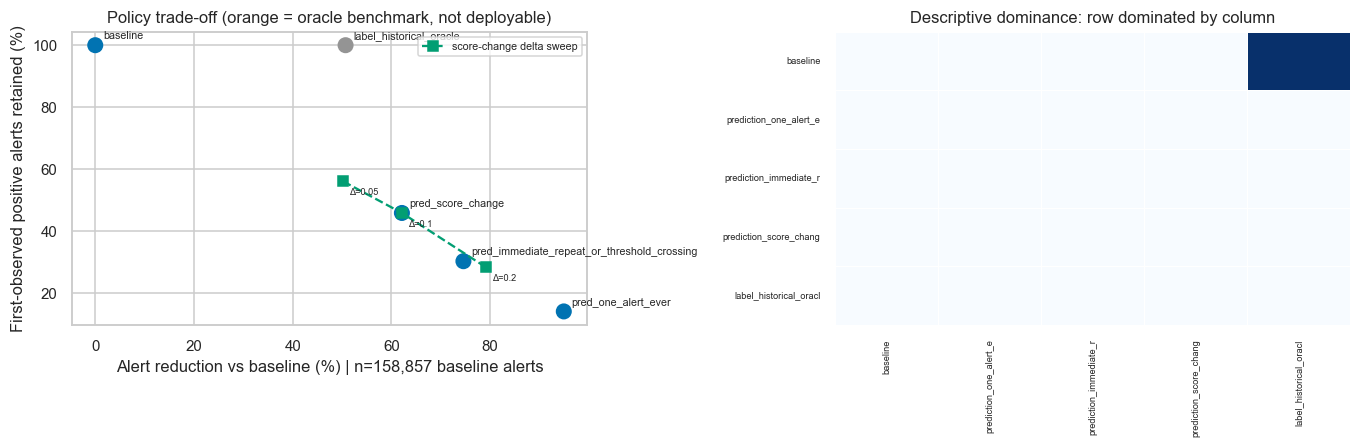

In [14]:
pol_rows = []
for pol in POLICIES:
    def gv(metric: str) -> Tuple[float, float, float]:
        m = f"policy_{pol}_{metric}"
        r = CI[CI["metric"] == m]
        if r.empty:
            return np.nan, np.nan, np.nan
        r = r.iloc[0]
        return float(r["point_estimate"]), float(r["ci_lower"]), float(r["ci_upper"])

    f = apply_policy(PRIMARY, pol)
    pos_m = PRIMARY["label_current"] == 1
    lab_prior = PRIMARY["label_ever_prior"].fillna(False).astype(bool)
    pred_prior = PRIMARY["fired_ever_prior"].fillna(False).astype(bool)
    base_f = apply_policy(PRIMARY, "baseline")
    per_pt = (PRIMARY.loc[f].groupby("Patient ID").size()
              .reindex(PRIMARY["Patient ID"].unique(), fill_value=0))
    n, lo, hi = gv("fired")
    red, rlo, rhi = gv("pct_reduction")
    ret, tlo, thi = gv("first_observed_retention_pct")
    lost, llo, lhi = gv("patients_losing_all_first_observed")
    pol_rows.append({
        "policy": pol, "status": POLICY_STATUS[pol],
        "total_fired_alerts": int(f.sum()),
        "alerts_per_100_followup_images": round(100 * int(f.sum()) / n_img, 3),
        "alert_reduction_vs_baseline": int(base_f.sum() - f.sum()),
        "pct_reduction_vs_baseline": round(red, 3),
        "pct_reduction_ci": f"{rlo:.2f} to {rhi:.2f}",
        "false_alert_reduction": int((base_f & ~pos_m).sum() - (f & ~pos_m).sum()),
        "label_redundant_reduction":
            int((base_f & pos_m & lab_prior).sum() - (f & pos_m & lab_prior).sum()),
        "prediction_redundant_reduction":
            int((base_f & pos_m & pred_prior).sum() - (f & pos_m & pred_prior).sum()),
        "first_observed_positive_alert_retention_pct": round(ret, 3),
        "retention_ci": f"{tlo:.2f} to {thi:.2f}",
        "missed_positive_change":
            int((pos_m & ~f).sum() - (pos_m & ~base_f).sum()),
        "pct_patients_with_at_least_one_alert": round(100 * float((per_pt > 0).mean()), 3),
        "patients_losing_all_baseline_first_observed_positive_alerts": int(lost),
        "pct_patients_losing_all_first_observed": round(100 * lost / n_pt, 3),
        "median_alerts_per_patient": float(per_pt.median()),
        "iqr_alerts_per_patient": f"{per_pt.quantile(.25):.1f}-{per_pt.quantile(.75):.1f}"})
POLICY = pd.DataFrame(pol_rows)

dom = []
for _, a in POLICY.iterrows():
    dominated_by = []
    for _, b in POLICY.iterrows():
        if a["policy"] == b["policy"]:
            continue
        ge = (b["pct_reduction_vs_baseline"] >= a["pct_reduction_vs_baseline"]
              and b["first_observed_positive_alert_retention_pct"]
              >= a["first_observed_positive_alert_retention_pct"])
        strict = (b["pct_reduction_vs_baseline"] > a["pct_reduction_vs_baseline"]
                  or b["first_observed_positive_alert_retention_pct"]
                  > a["first_observed_positive_alert_retention_pct"])
        if ge and strict:
            dominated_by.append(b["policy"])
    dom.append({"policy": a["policy"], "descriptively_dominated": bool(dominated_by),
                "dominated_by": "|".join(dominated_by)})
POLICY = POLICY.merge(pd.DataFrame(dom), on="policy")
save_table(POLICY, "part3_policy_tradeoff_and_dominance")
print(POLICY[["policy", "status", "alerts_per_100_followup_images",
              "pct_reduction_vs_baseline", "pct_reduction_ci",
              "first_observed_positive_alert_retention_pct", "retention_ci",
              "descriptively_dominated"]].to_string(index=False))
print("\nDominance here is an operational trade-off comparison between alert reduction and "
      "first-observed retention. A non-dominated policy is not thereby safe, optimal, "
      "clinically superior, or deployable.")

delta_rows = []
for d in SCORE_CHANGE_DELTAS:
    f = apply_policy(PRIMARY, "prediction_score_change", delta=d)
    pos_m = PRIMARY["label_current"] == 1
    lab_prior = PRIMARY["label_ever_prior"].fillna(False).astype(bool)
    base_f = apply_policy(PRIMARY, "baseline")
    base_fo = int((base_f & pos_m & ~lab_prior).sum())
    fo = int((f & pos_m & ~lab_prior).sum())
    lost = int(((PRIMARY.loc[base_f & pos_m & ~lab_prior].groupby("Patient ID").size() > 0)
                & (PRIMARY.loc[f & pos_m & ~lab_prior].groupby("Patient ID").size()
                   .reindex(PRIMARY.loc[base_f & pos_m & ~lab_prior]["Patient ID"].unique(),
                            fill_value=0) == 0)).sum())
    delta_rows.append({
        "score_change_delta": d, "fired_alerts": int(f.sum()),
        "alerts_per_100_followup_images": round(100 * int(f.sum()) / n_img, 3),
        "pct_reduction_vs_baseline": round(100 * (base_f.sum() - f.sum()) / base_f.sum(), 3),
        "first_observed_positive_alert_retention_pct": round(100 * fo / max(base_fo, 1), 3),
        "patients_losing_all_baseline_first_observed_positive_alerts": lost})
DELTA = pd.DataFrame(delta_rows)
save_table(DELTA, "part3_score_change_delta_sensitivity")
print(); print(DELTA.to_string(index=False))
print("\nScore change is a change in model output between adjacent encounters. It is not "
      "radiographic deterioration, clinical progression, or evidence of safe suppression.")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
cols = [CB[7] if POLICY_STATUS[p].startswith("retro") else CB[0] for p in POLICY["policy"]]
axes[0].scatter(POLICY["pct_reduction_vs_baseline"],
                POLICY["first_observed_positive_alert_retention_pct"], c=cols, s=90)
for _, r in POLICY.iterrows():
    axes[0].annotate(r["policy"].replace("prediction_", "pred_"),
                     (r["pct_reduction_vs_baseline"],
                      r["first_observed_positive_alert_retention_pct"]),
                     fontsize=7, xytext=(5, 4), textcoords="offset points")
axes[0].plot(DELTA["pct_reduction_vs_baseline"],
             DELTA["first_observed_positive_alert_retention_pct"],
             marker="s", ls="--", color=CB[2], label="score-change delta sweep")
for _, r in DELTA.iterrows():
    axes[0].annotate(f"Δ={r['score_change_delta']}",
                     (r["pct_reduction_vs_baseline"],
                      r["first_observed_positive_alert_retention_pct"]),
                     fontsize=6, xytext=(4, -9), textcoords="offset points")
axes[0].set_xlabel(f"Alert reduction vs baseline (%) | n={n_fired:,} baseline alerts")
axes[0].set_ylabel("First-observed positive alerts retained (%)")
axes[0].set_title("Policy trade-off (orange = oracle benchmark, not deployable)")
axes[0].legend(fontsize=7)

mat = np.zeros((len(POLICY), len(POLICY)))
for i, a in enumerate(POLICY["policy"]):
    for j, b in enumerate(POLICY["policy"]):
        mat[i, j] = 1 if b in POLICY.loc[POLICY["policy"] == a,
                                         "dominated_by"].iat[0].split("|") else 0
sns.heatmap(mat, ax=axes[1], cmap="Blues", cbar=False, linewidths=.5,
            xticklabels=[p[:22] for p in POLICY["policy"]],
            yticklabels=[p[:22] for p in POLICY["policy"]])
axes[1].set_title("Descriptive dominance: row dominated by column")
axes[1].tick_params(labelsize=6)
fig.tight_layout()
save_figure(fig, "fig10_policy_tradeoff_dominance")
plt.show()

## 11. Subgroup and sequence-position uncertainty summaries

Descriptive and unadjusted. Groups differ in prevalence, acquisition context and imaging
frequency, so differences here describe those groups as observed and support no causal,
fairness, bias, discrimination or inequity conclusion. Ordinal positions are never
translated into elapsed time.

  table  -> part3_subgroup_uncertainty.csv  (8 x 18)
  table  -> part3_sequence_position_uncertainty.csv  (7 x 18)
        subgroup           level  n_patients  n_images  fired_alerts  redundant_share_of_correct_pct  ci_lower  ci_upper  unstable_cell
       sex_group               F         599      9474         66271                          82.253    80.644    83.784          False
       sex_group               M         825     13325         92586                          82.927    81.522    84.310          False
        age_band           40-60         702     10552         74811                          82.542    80.764    84.049          False
        age_band             <40         436      7270         47043                          83.868    82.037    85.621          False
        age_band             >60         369      4974         36972                          81.293    78.569    83.434          False
        age_band Missing/Invalid           3         3            31 

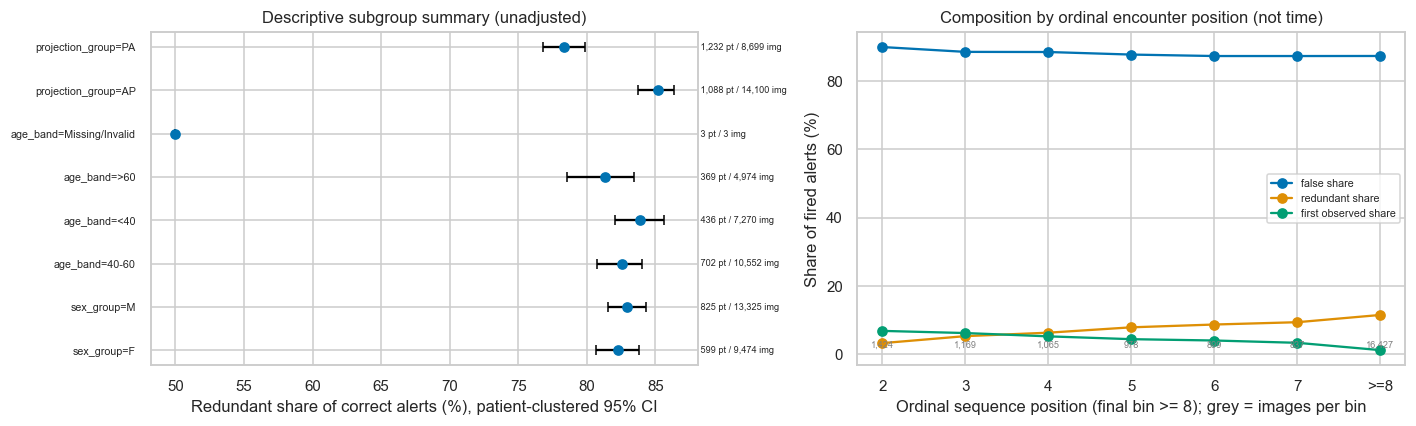

In [15]:
def subgroup_bootstrap_ci(d: pd.DataFrame, metric_fn: Callable[[np.ndarray], float],
                          agg_fn: Callable[[pd.DataFrame], pd.DataFrame],
                          n_boot: int = N_BOOT, seed: int = RANDOM_SEED
                          ) -> Tuple[float, float, float]:
    """Patient-clustered percentile CI for one aggregated ratio within a subgroup."""
    a = agg_fn(d).to_numpy()
    if len(a) < MIN_SUBGROUP_PATIENTS:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    point = metric_fn(a.sum(axis=0))
    draws = [metric_fn(a[rng.integers(0, len(a), len(a))].sum(axis=0)) for _ in range(n_boot)]
    draws = np.asarray([x for x in draws if np.isfinite(x)])
    if len(draws) < 0.9 * n_boot:
        return point, np.nan, np.nan
    return point, float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5))


def _agg(d: pd.DataFrame) -> pd.DataFrame:
    c = d["alert_category"]
    return d.assign(_red=(c == "redundant_alert").astype(int),
                    _fo=(c == "first_observed_positive_alert").astype(int),
                    _fa=(c == "false_alert").astype(int),
                    _one=1).groupby("Patient ID")[["_red", "_fo", "_fa"]].sum()


PRIMARY["position_bin"] = np.where(
    PRIMARY["sequence_position_ordinal"] >= SEQUENCE_POSITION_K, f">={SEQUENCE_POSITION_K}",
    PRIMARY["sequence_position_ordinal"].astype(int).astype(str))

sub_rows = []
for col in ("sex_group", "age_band", "projection_group", "position_bin"):
    for lvl, d in PRIMARY.groupby(col, observed=True):
        c = d["alert_category"].value_counts()
        fired = int(sum(c.get(k, 0) for k in FIRED_CATEGORIES))
        correct = int(c.get("redundant_alert", 0) + c.get("first_observed_positive_alert", 0))
        nimg_l, npt_l = d["Image Index"].nunique(), d["Patient ID"].nunique()
        npos_l = int((d["label_current"] == 1).sum())
        per_img = (d[d["alert_category"].isin(FIRED_CATEGORIES)].groupby("Image Index").size()
                   .reindex(d["Image Index"].unique(), fill_value=0))
        unstable = (npt_l < MIN_SUBGROUP_PATIENTS or nimg_l < MIN_SUBGROUP_IMAGES
                    or npos_l < MIN_SUBGROUP_POSITIVES or fired < MIN_SUBGROUP_FIRED)
        pt, lo, hi = (np.nan, np.nan, np.nan) if unstable else subgroup_bootstrap_ci(
            d, lambda s: 100 * s[0] / (s[0] + s[1]) if (s[0] + s[1]) else np.nan, _agg)
        bf = apply_policy(d, "baseline"); of_ = apply_policy(d, "prediction_one_alert_ever")
        sub_rows.append({
            "subgroup": col, "level": str(lvl), "n_patients": npt_l, "n_images": nimg_l,
            "n_opportunities": len(d), "n_positive_labels": npos_l, "fired_alerts": fired,
            "mean_alerts_per_radiograph": round(float(per_img.mean()), 4),
            "alerts_per_100_images": round(100 * fired / nimg_l, 3),
            "false_share_pct": round(100 * c.get("false_alert", 0) / fired, 3) if fired else np.nan,
            "redundant_share_pct": round(100 * c.get("redundant_alert", 0) / fired, 3) if fired else np.nan,
            "first_observed_share_pct":
                round(100 * c.get("first_observed_positive_alert", 0) / fired, 3) if fired else np.nan,
            "redundant_share_of_correct_pct": round(pt, 3) if np.isfinite(pt) else (
                round(100 * c.get("redundant_alert", 0) / correct, 3) if correct else np.nan),
            "ci_lower": round(lo, 3) if np.isfinite(lo) else np.nan,
            "ci_upper": round(hi, 3) if np.isfinite(hi) else np.nan,
            "pct_reduction_one_alert_ever":
                round(100 * (bf.sum() - of_.sum()) / bf.sum(), 3) if bf.sum() else np.nan,
            "unstable_cell": unstable,
            "instability_reason": "" if not unstable else
            f"patients<{MIN_SUBGROUP_PATIENTS} or images<{MIN_SUBGROUP_IMAGES} or "
            f"positives<{MIN_SUBGROUP_POSITIVES} or fired<{MIN_SUBGROUP_FIRED}"})
SUB = pd.DataFrame(sub_rows)
save_table(SUB[SUB["subgroup"] != "position_bin"], "part3_subgroup_uncertainty")
save_table(SUB[SUB["subgroup"] == "position_bin"], "part3_sequence_position_uncertainty")
print(SUB[SUB["subgroup"] != "position_bin"][
    ["subgroup", "level", "n_patients", "n_images", "fired_alerts",
     "redundant_share_of_correct_pct", "ci_lower", "ci_upper", "unstable_cell"]]
      .to_string(index=False))
print(f"\n{int(SUB['unstable_cell'].sum())} cell(s) below the stability minima. Counts "
      "retained, intervals suppressed, no comparative conclusion drawn. These are "
      "unadjusted descriptions and support no fairness or bias claim.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
s1 = SUB[SUB["subgroup"] != "position_bin"].copy()
s1["label"] = s1["subgroup"] + "=" + s1["level"]
y = np.arange(len(s1))
axes[0].errorbar(s1["redundant_share_of_correct_pct"], y,
                 xerr=[np.where(s1["ci_lower"].notna(),
                                s1["redundant_share_of_correct_pct"] - s1["ci_lower"], 0),
                       np.where(s1["ci_upper"].notna(),
                                s1["ci_upper"] - s1["redundant_share_of_correct_pct"], 0)],
                 fmt="o", capsize=3,
                 color=CB[0], ecolor="black")
axes[0].set_yticks(y); axes[0].set_yticklabels(s1["label"], fontsize=7)
for i, (n, m) in enumerate(zip(s1["n_patients"], s1["n_images"])):
    axes[0].text(axes[0].get_xlim()[1], i, f" {n:,} pt / {m:,} img", fontsize=6, va="center")
axes[0].set_xlabel("Redundant share of correct alerts (%), patient-clustered 95% CI")
axes[0].set_title("Descriptive subgroup summary (unadjusted)")

s2 = SUB[SUB["subgroup"] == "position_bin"].copy()
order = [str(i) for i in range(2, SEQUENCE_POSITION_K)] + [f">={SEQUENCE_POSITION_K}"]
s2["level"] = pd.Categorical(s2["level"], order, ordered=True)
s2 = s2.sort_values("level").dropna(subset=["level"])
for i, k in enumerate(["false_share_pct", "redundant_share_pct", "first_observed_share_pct"]):
    axes[1].plot(s2["level"].astype(str), s2[k], marker="o", color=CB[i],
                 label=k.replace("_pct", "").replace("_", " "))
for x, m in zip(s2["level"].astype(str), s2["n_images"]):
    axes[1].annotate(f"{m:,}", (x, 2), fontsize=6, ha="center", color="grey")
axes[1].set_xlabel(f"Ordinal sequence position (final bin >= {SEQUENCE_POSITION_K}); "
                   "grey = images per bin")
axes[1].set_ylabel("Share of fired alerts (%)")
axes[1].set_title("Composition by ordinal encounter position (not time)")
axes[1].legend(fontsize=7)
fig.tight_layout()
save_figure(fig, "fig11_subgroup_and_position")
plt.show()

## 12. Final tables, figures, artifact manifest, and audit checklist

In [16]:
if NOT_ESTIMABLE:
    save_table(pd.DataFrame(NOT_ESTIMABLE), "part3_not_estimable_register")

REQUIRED_TABLES = [
    "part3_primary_estimand_reconstruction.csv", "part3_primary_alert_multiplicity.csv",
    "part3_primary_patient_alert_distribution.csv", "part3_bootstrap_replicates.parquet",
    "part3_primary_bootstrap_ci.csv", "part3_policy_bootstrap_ci.csv",
    "part3_threshold_sensitivity.csv", "part3_threshold_pathology_metrics.csv",
    "part3_redundancy_definition_comparison.csv",
    "part3_label_prediction_history_mismatch.csv", "part3_cohort_sensitivity.csv",
    "part3_pathology_level_results.csv", "part3_pathology_bootstrap_ci.csv",
    "part3_google_label_schema_audit.csv", "part3_google_overlap_audit.csv",
    "part3_google_mapping_table.csv", "part3_google_label_agreement.csv",
    "part3_google_model_reference_sensitivity.csv",
    "part3_policy_tradeoff_and_dominance.csv", "part3_score_change_delta_sensitivity.csv",
    "part3_subgroup_uncertainty.csv", "part3_sequence_position_uncertainty.csv",
    "part3_detection_gap_by_pathology.csv", "part3_within_episode_severity_control.csv",
]
REQUIRED_FIGURES = [f"fig{i:02d}" for i in range(1, 12)]
missing_t = [t for t in REQUIRED_TABLES if t not in _SAVED_TABLES]
missing_f = [f for f in REQUIRED_FIGURES if not any(s.startswith(f) for s in _SAVED_FIGURES)]

_epi_ok = (not EPI.empty) if "EPI" in dir() else False
checks = [
    ("Part 1 and Part 2 manifests found", "PASS", f"{P2_MANIFEST['run_tag']}"),
    ("Part 2 audit had zero failures", "PASS" if not len(_p2_fail) else "FAIL",
     f"{_p2_warn} WARN"),
    ("fingerprints align", "PASS" if FP["aligned"] else "WARN", FP["part1_fingerprint"][:12]),
    ("selected thresholds frozen and complete",
     "PASS" if len(THRESHOLDS) == len(PATHOLOGIES) else "FAIL", f"{len(PATHOLOGIES)} labels"),
    ("no patient overlap", "PASS", "asserted on split assignments"),
    ("no duplicate image-pathology rows", "PASS", "asserted on stream and predictions"),
    ("primary reconstruction matches Part 2", "PASS",
     f"{n_fired:,} fired alerts, all categories identical"),
    ("no index or warm-up rows in primary cohort", "PASS",
     f"{int(STREAM['is_index_encounter'].sum()):,} excluded upstream"),
    ("bootstrap is patient-clustered", "PASS", f"{n_pt:,} patients resampled as clusters"),
    ("bootstrap resumable and complete",
     "PASS" if len(REPS) >= N_BOOT else "WARN", f"{len(REPS):,}/{N_BOOT:,} replicates"),
    ("no model retraining occurred", "PASS", "frozen probabilities only"),
    ("no test-based threshold selection", "PASS",
     "frozen thresholds; alternative recovered from the validation grid"),
    ("threshold sensitivity uses frozen probabilities", "PASS",
     f"{len(OP_POINTS)} operating points"),
    ("history families remain distinct", "PASS", "label vs prediction reported separately"),
    ("oracle not described as deployable or a universal bound", "PASS",
     "framed as a reference point"),
    ("age integrity not interpreted as chronology validation", "PASS",
     "data-consistency restriction only"),
    ("adjudicated subset labelled within-dataset sensitivity", "PASS",
     "never called external validation"),
    ("severity confound addressed by within-episode analysis",
     "PASS" if _epi_ok else "WARN",
     f"{int(EPISODE_RESULT.loc[0, 'n_episodes']):,} episodes" if _epi_ok else "not estimable"),
    ("estimand B provenance recorded", "PASS", "exploratory-confirmatory, in manifest"),
    ("all planned tables have a result or not-estimable record",
     "PASS" if not missing_t else "FAIL", f"missing: {missing_t or 'none'}"),
    ("all planned figures saved or marked not estimable",
     "PASS" if not missing_f else "WARN", f"missing: {missing_f or 'none'}"),
    ("run mode", "WARN" if FAST_MODE else "PASS",
     "SMOKE TEST" if FAST_MODE else f"full, {N_BOOT} replicates"),
]
CHECK = pd.DataFrame(checks, columns=["check", "status", "detail"])
print(CHECK.to_string(index=False))
save_table(CHECK, "part3_audit_checklist")

MANIFEST = {
    "created_utc": datetime.now(timezone.utc).isoformat(), "run_tag": RUN_TAG,
    "fast_mode": FAST_MODE, "n_bootstrap": int(N_BOOT),
    "part1_fingerprint": FP, "part2_run_tag": P2_MANIFEST["run_tag"],
    "backbone": P2_MANIFEST["embedding_meta"].get("backbone_id"),
    "labels": PATHOLOGIES, "selected_thresholds": THRESH_MAP,
    "primary_redundancy_definition": PRIMARY_REDUNDANCY,
    "primary_point_estimates": {k: (None if not np.isfinite(v) else float(v))
                                for k, v in POINT.items()},
    "estimand_B_status": CONFIG["estimand_B_status"],
    "within_episode_estimable": bool(_epi_ok),
    "validation_auroc_floor": VALIDATION_AUROC_FLOOR,
    "labels_passing_floor": _floor_labels,
    "not_estimable": NOT_ESTIMABLE,
    "tables_saved": sorted(_SAVED_TABLES), "figures_saved": sorted(_SAVED_FIGURES),
    "config": CONFIG,
}
(LOGS / "part3_run_manifest.json").write_text(json.dumps(MANIFEST, indent=2, default=str))

n_fail = int((CHECK["status"] == "FAIL").sum()); n_warn = int((CHECK["status"] == "WARN").sum())
print(f"\n{'=' * 76}")
print(f"PART 3 RESULT: {n_fail} FAIL, {n_warn} WARN, "
      f"{int((CHECK['status'] == 'PASS').sum())} PASS   [{RUN_TAG.upper()}]")
if NOT_ESTIMABLE:
    print(f"{len(NOT_ESTIMABLE)} planned analysis/analyses recorded as not estimable.")
print("Resolve every FAIL before interpretation." if n_fail else
      "Part 3 complete. All three parts are reproducible from the saved manifests.")
print("=" * 76)
gc.collect()

  table  -> part3_not_estimable_register.csv  (1 x 5)
                                                   check status                                                            detail
                       Part 1 and Part 2 manifests found   PASS                                           full_densenet121_sens50
                          Part 2 audit had zero failures   PASS                                                            0 WARN
                                      fingerprints align   PASS                                                      ff1425a89979
                 selected thresholds frozen and complete   PASS                                                         13 labels
                                      no patient overlap   PASS                                     asserted on split assignments
                       no duplicate image-pathology rows   PASS                                asserted on stream and predictions
                   primary reconstru

25032

## 13. Interpretation limits and reproducibility handoff

### 13.1 What the primary result is conditional on

One retrospective corpus, weak report-derived labels, one frozen image representation,
one patient-level split, and thresholds selected on one validation split. Change any of
those and the numbers move; sections 6 through 8 show by how much within this corpus.

### 13.2 Limits that constrain every number above

1. **Alert burden is pathology-specific.** One radiograph carries as many opportunities
   as there are selected labels, so alerts per 100 radiographs exceeds 100 and is not a
   percentage of radiographs. Section 4's multiplicity table is the correct companion to
   any rate quoted from this work.
2. **Label-history redundancy is retrospective.** It does not establish that a repeat
   alert would be clinically redundant. A finding present on a prior radiograph may still
   warrant re-alerting: it may have changed, become newly relevant, or never have been
   communicated to the clinician now looking at it.
3. **First-observed positive labels are not incident disease.** They are the first
   positive weak label in the available sequence. Prior imaging outside this corpus is
   invisible, so this is an upper bound on first presentation.
4. **Test-only sequence history is deliberately conservative.** History is rebuilt within
   the held-out split, so no training or validation encounter can enter a history window.
   That is an evaluation safeguard, not a simulation of a patient's complete record.
5. **Threshold choice materially alters both alert rate and composition.** Section 6
   quantifies this. No operating point here is recommended.
6. **Patient-clustered intervals quantify sampling variability within this held-out
   cohort only.** They say nothing about label error, dataset shift, site differences, or
   workflow uncertainty, all of which are larger sources of doubt than sampling.
7. **The adjudicated subset is a within-dataset label-reference sensitivity analysis.**
   Those labels are a relabelling of the same images. Nothing here is external validation
   and nothing supports a transportability claim.
8. **The detection gap has a residual confound.** The within-episode analysis in section 7
   holds patient and pathology constant, which removes between-patient severity and
   between-finding conspicuity. It does not remove genuine change in a finding across an
   episode. Report the within-episode estimate as the confounder-controlled figure and
   state the residual explicitly.
9. **Subgroup results are unadjusted descriptions.** No fairness, bias, discrimination or
   inequity conclusion follows from them.
10. **Weak-label instability is not separable from clinical change.** A label flipping
    negative to positive between adjacent encounters is indistinguishable, in these data,
    from a finding genuinely appearing.
11. **No policy is safe, optimal, clinically beneficial, or deployment-ready.** No
    clinician received an alert and no workflow was observed. The label-history oracle is
    not deployable and is not a universal upper bound on prediction-history policies.
12. **Calibration was not evaluated.** Thresholds were chosen on validation operating
    characteristics, not on calibrated risk.

All findings should be described as properties of a retrospective serial-alert simulation
on this corpus, not as properties of chest radiography, of clinical decision support, or
of any deployed system.

### 13.3 Reproducibility handoff

`part3_run_manifest.json` records the Part 1 fingerprint, the Part 2 run tag and backbone,
the frozen label set and thresholds, every primary point estimate, the provenance of
estimand B, the labels passing the validation discrimination floor, the not-estimable
register, and the full configuration. With the Part 1 and Part 2 manifests it is
sufficient to reproduce all three parts from the raw corpus.

Bootstrap chunks remain on disk under `bootstrap_chunks/`. Delete them to force a fresh
resampling run; leave them to resume an interrupted one.

### Output Figure 1

In [17]:
# =====================================================================
# Figure 1 - four-component alert-stream characterisation (black & white)
# Reads saved Part 3 tables; no other cell state required.
# =====================================================================
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

TABLES = Path(r"C:\Users\kruta\Downloads\part3_outputs\full\tables")
FIGDIR = Path(r"C:\Users\kruta\Downloads\part3_outputs\full\figures")

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 8.5, "axes.linewidth": 0.8,
    "axes.edgecolor": "black", "savefig.dpi": 300, "savefig.bbox": "tight",
    "hatch.linewidth": 0.6,
})
GREY = {"dark": "0.20", "mid": "0.55", "light": "0.85", "white": "white"}

rec   = pd.read_csv(TABLES / "part3_primary_estimand_reconstruction.csv").set_index("alert_category")
mult  = pd.read_csv(TABLES / "part3_primary_alert_multiplicity.csv")
ci    = pd.read_csv(TABLES / "part3_primary_bootstrap_ci.csv").set_index("metric")
red   = pd.read_csv(TABLES / "part3_redundancy_definition_comparison.csv")
epi   = pd.read_csv(TABLES / "part3_within_episode_severity_control.csv")
gap   = pd.read_csv(TABLES / "part3_detection_gap_by_pathology.csv")

n_img  = int(rec["n_followup_images"].iloc[0])
n_pt   = int(rec["n_patients"].iloc[0])
n_fire = int(rec["total_fired"].iloc[0])
n_corr = int(rec["total_correct_alerts"].iloc[0])
g = lambda m, c: float(ci.loc[m, c])

fig = plt.figure(figsize=(7.0, 6.6))
gs  = fig.add_gridspec(2, 2, hspace=0.52, wspace=0.34,
                       height_ratios=[1.0, 1.25])

# ---------------- A. multiplicity ------------------------------------
axA = fig.add_subplot(gs[0, 0])
bars = axA.bar(mult["fired_alerts_on_radiograph"], mult["pct_of_radiographs"],
               color=GREY["light"], edgecolor="black", lw=0.8, width=0.68)
bars[-1].set_hatch("///")
for b, v in zip(bars, mult["pct_of_radiographs"]):
    axA.text(b.get_x() + b.get_width()/2, v + 1.5, f"{v:.1f}",
             ha="center", fontsize=7.5)
axA.set_ylim(0, 100)
axA.set_xlabel("Concurrent alerts on one radiograph", fontsize=8)
axA.set_ylabel("Radiographs (%)", fontsize=8)
axA.set_title("A  Alert multiplicity", loc="left", fontsize=9, fontweight="bold")
axA.text(0.03, 0.72,
         f"mean {g('mean_alerts_per_image','point_estimate'):.2f} of 13 findings\n"
         f"{g('pct_images_with_at_least_one_alert','point_estimate'):.1f}% receive "
         f"$\\geq$1 alert\nmedian {g('median_alerts_per_patient','point_estimate'):.0f} "
         f"alerts per patient",
         transform=axA.transAxes, fontsize=7.2, va="top", linespacing=1.5)
axA.spines[["top", "right"]].set_visible(False)

# ---------------- B. decomposition, two denominators ------------------
axB = fig.add_subplot(gs[0, 1])
cats  = ["false_alert", "redundant_alert", "first_observed_positive_alert"]
names = ["False", "Redundant", "First-observed"]
fills = [GREY["white"], GREY["mid"], GREY["dark"]]
hatch = ["...", "", ""]
rowsY = [1, 0]
allf  = [float(rec.loc[c, "share_of_fired_alerts_pct"]) for c in cats]
corr  = [0.0] + [float(rec.loc[c, "share_of_correct_alerts_pct"]) for c in cats[1:]]
for vals, y in ((allf, 1), (corr, 0)):
    left = 0.0
    for v, f, h in zip(vals, fills, hatch):
        if v <= 0:
            continue
        axB.barh(y, v, left=left, height=0.5, color=f, edgecolor="black",
                 lw=0.8, hatch=h)
        if v > 12:
            axB.text(left + v/2, y, f"{v:.1f}%", ha="center", va="center",
                     fontsize=7.5, color="white" if f == GREY["dark"] else "black")
        else:
            dx = 14 if f == GREY["mid"] else 40
            axB.annotate(f"{v:.1f}%", (left + v/2, y), fontsize=7,
                         xytext=(dx, 26 if y == 1 else -26),
                         textcoords="offset points", ha="center",
                         arrowprops=dict(arrowstyle="-", lw=0.6, color="0.4"))
        left += v
axB.errorbar(g("redundant_share_of_correct_pct", "point_estimate"), 0,
             xerr=[[g("redundant_share_of_correct_pct", "point_estimate")
                    - g("redundant_share_of_correct_pct", "ci_lower")],
                   [g("redundant_share_of_correct_pct", "ci_upper")
                    - g("redundant_share_of_correct_pct", "point_estimate")]],
             fmt="none", ecolor="black", capsize=2.5, lw=1.0)
axB.set_yticks(rowsY)
axB.set_yticklabels([f"All fired\n(n={n_fire:,})", f"Correct only\n(n={n_corr:,})"],
                    fontsize=7.8)
axB.set_xlim(0, 100); axB.set_ylim(-0.95, 1.95)
axB.set_xlabel("Share of alerts (%)", fontsize=8)
axB.set_title("B  Decomposition", loc="left", fontsize=9, fontweight="bold")
handles = [plt.Rectangle((0, 0), 1, 1, fc=f, ec="black", lw=0.8, hatch=h)
           for f, h in zip(fills, hatch)]
axB.legend(handles, names, fontsize=7, loc="upper center",
           bbox_to_anchor=(0.5, -0.30), ncol=3, frameon=False, handlelength=1.5)
axB.spines[["top", "right", "left"]].set_visible(False)

# ---------------- C. definition sensitivity ---------------------------
axC = fig.add_subplot(gs[1, 0])
order = ["label_historical", "label_immediate_prior",
         "prediction_historical", "prediction_immediate_prior"]
lbl = ["Label\never", "Label\nimmed.", "Predict.\never", "Predict.\nimmed."]
vals = [float(red.loc[red["redundancy_definition"] == o,
                      "redundant_share_of_correct_pct"].iloc[0]) for o in order]
cols = [GREY["mid"], GREY["mid"], GREY["light"], GREY["light"]]
hats = ["", "", "\\\\\\", "\\\\\\"]
b = axC.bar(range(4), vals, color=cols, edgecolor="black", lw=0.8,
            hatch=hats, width=0.66)
for i, v in enumerate(vals):
    axC.text(i, v + 2, f"{v:.1f}", ha="center", fontsize=8)
axC.axhline(vals[0], ls=(0, (4, 3)), color="0.4", lw=0.9)
axC.annotate("", xy=(1.42, vals[1]), xytext=(1.42, vals[0]),
             arrowprops=dict(arrowstyle="<->", lw=0.9, color="black"))
axC.text(1.52, (vals[0] + vals[1]) / 2, "39.8 pp\nswing", fontsize=7.2,
         va="center", linespacing=1.4)
axC.set_xticks(range(4)); axC.set_xticklabels(lbl, fontsize=7.0, linespacing=1.4)
axC.set_ylim(0, 112); axC.set_ylabel("Redundant share of\ncorrect alerts (%)", fontsize=8)
axC.set_title("C  Redundancy is definition-dependent", loc="left",
              fontsize=9, fontweight="bold")
axC.spines[["top", "right"]].set_visible(False)

# ---------------- D. within-episode control ---------------------------
axD = fig.add_subplot(gs[1, 1])
ep = epi.set_index("stratum")
m = gap.merge(epi[["stratum", "within_episode_gap_pp"]],
              left_on="pathology", right_on="stratum", how="inner")
m = m.sort_values("gap_pp").reset_index(drop=True)
y = np.arange(len(m))
axD.hlines(y, m["within_episode_gap_pp"], m["gap_pp"], color="0.6", lw=1.0, zorder=1)
axD.scatter(m["gap_pp"], y, s=26, facecolor="white", edgecolor="black",
            lw=0.9, zorder=3, label="Unadjusted")
axD.scatter(m["within_episode_gap_pp"], y, s=26, color="black", zorder=3,
            label="Within-episode")
axD.axvline(0, color="black", lw=0.8)
yo = len(m) + 0.9
o_un, o_wi = 11.948, float(ep.loc["overall", "within_episode_gap_pp"])
axD.hlines(yo, o_wi, o_un, color="black", lw=2.2, zorder=2)
axD.scatter([o_un], [yo], s=60, facecolor="white", edgecolor="black", lw=1.4, zorder=4)
axD.scatter([o_wi], [yo], s=60, color="black", zorder=4)
axD.errorbar(o_un, yo, xerr=[[o_un - 10.402], [13.652 - o_un]], fmt="none",
             ecolor="black", capsize=2.5, lw=1.0, zorder=4)
axD.errorbar(o_wi, yo, xerr=[[o_wi - float(ep.loc["overall", "gap_ci_lower"])],
                             [float(ep.loc["overall", "gap_ci_upper"]) - o_wi]],
             fmt="none", ecolor="black", capsize=2.5, lw=1.0, zorder=4)
axD.set_yticks(list(y) + [yo])
axD.set_yticklabels(list(m["pathology"].str.replace("_", " ")
                         .str.replace("Pleural Thickening", "Pleural thick.")) + ["OVERALL"],
                    fontsize=6.8)
axD.get_yticklabels()[-1].set_fontweight("bold")
axD.set_ylim(-0.8, yo + 0.9); axD.set_xlim(-19, 25)
axD.set_xlabel("Detection gap: previously seen minus\nfirst observed (percentage points)",
               fontsize=8)
axD.set_title("D  Severity confounding removed", loc="left",
              fontsize=9, fontweight="bold")
axD.legend(fontsize=7, frameon=False, handletextpad=0.3, loc="lower right",
           bbox_to_anchor=(1.02, -0.02))
axD.text(0.02, 0.40, "81% of the apparent\ngap was confounding\nby patient and finding",
         transform=axD.transAxes, fontsize=7.0, ha="left", linespacing=1.5)
axD.spines[["top", "right"]].set_visible(False)

fig.text(0.5, -0.015,
         f"Denominators: {n_img:,} held-out follow-up radiographs from {n_pt:,} patients, "
         f"13 findings, {n_fire:,} fired alerts.\nError bars are patient-clustered 95% "
         "confidence intervals (1,000 bootstrap replicates).",
         ha="center", fontsize=7.2, linespacing=1.5)

fig.savefig(FIGDIR / "Figure1.tiff", format="tiff",
            pil_kwargs={"compression": "tiff_lzw"})
fig.savefig(FIGDIR / "Figure1_preview.png")
print("saved Figure1.tiff")

saved Figure1.tiff
